In [1]:
from data.data_loader import load_data
from data.preprocessing import prepare_datasets, split_data
from features.engineering import FeatureEngineer
from visualization.eda import run_eda, freq_exposition, plot_qualitative_distributions
from models.frequency_model import train_frequency_model
from models.severity_model import train_severity_model, train_best_severity_model
from models.premium_model import build_premium_predictions
from models.frequency_model import evaluate_frequency_model
from models.severity_model import evaluate_severity_model

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_param_validation.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import csr_matrix, issparse


# Load data

In [2]:
data, data_sev = load_data()

qualitatives_var = data.drop(
    columns=['PolicyID']
    ).select_dtypes(include=['object', 'category']).columns

quantitatives_var = data.drop(
    columns=['PolicyID']
    ).select_dtypes(include=['float64', 'int64']).columns

# EDA

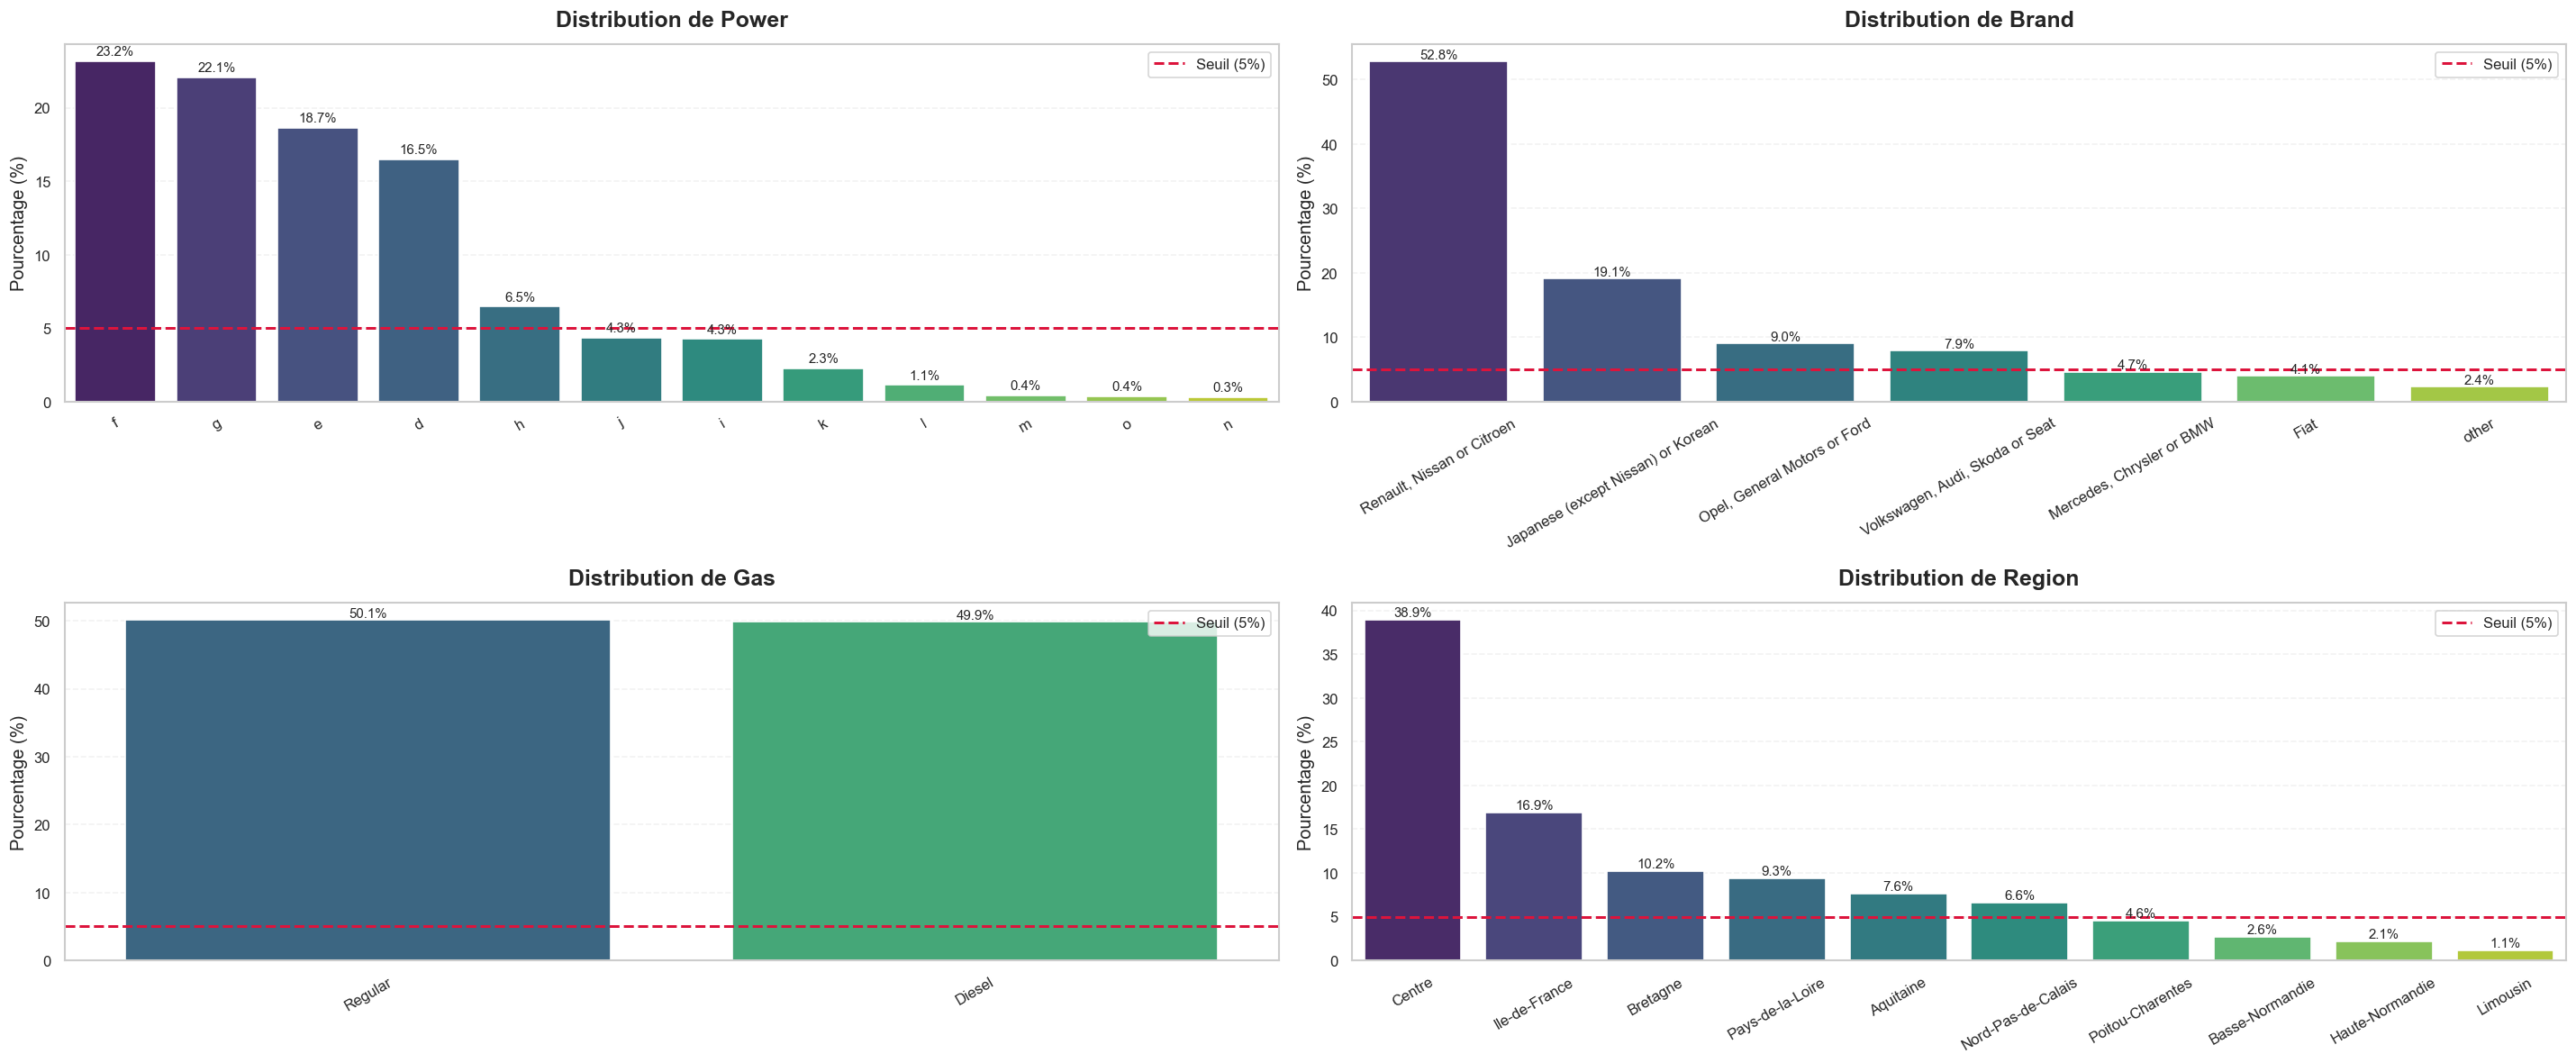

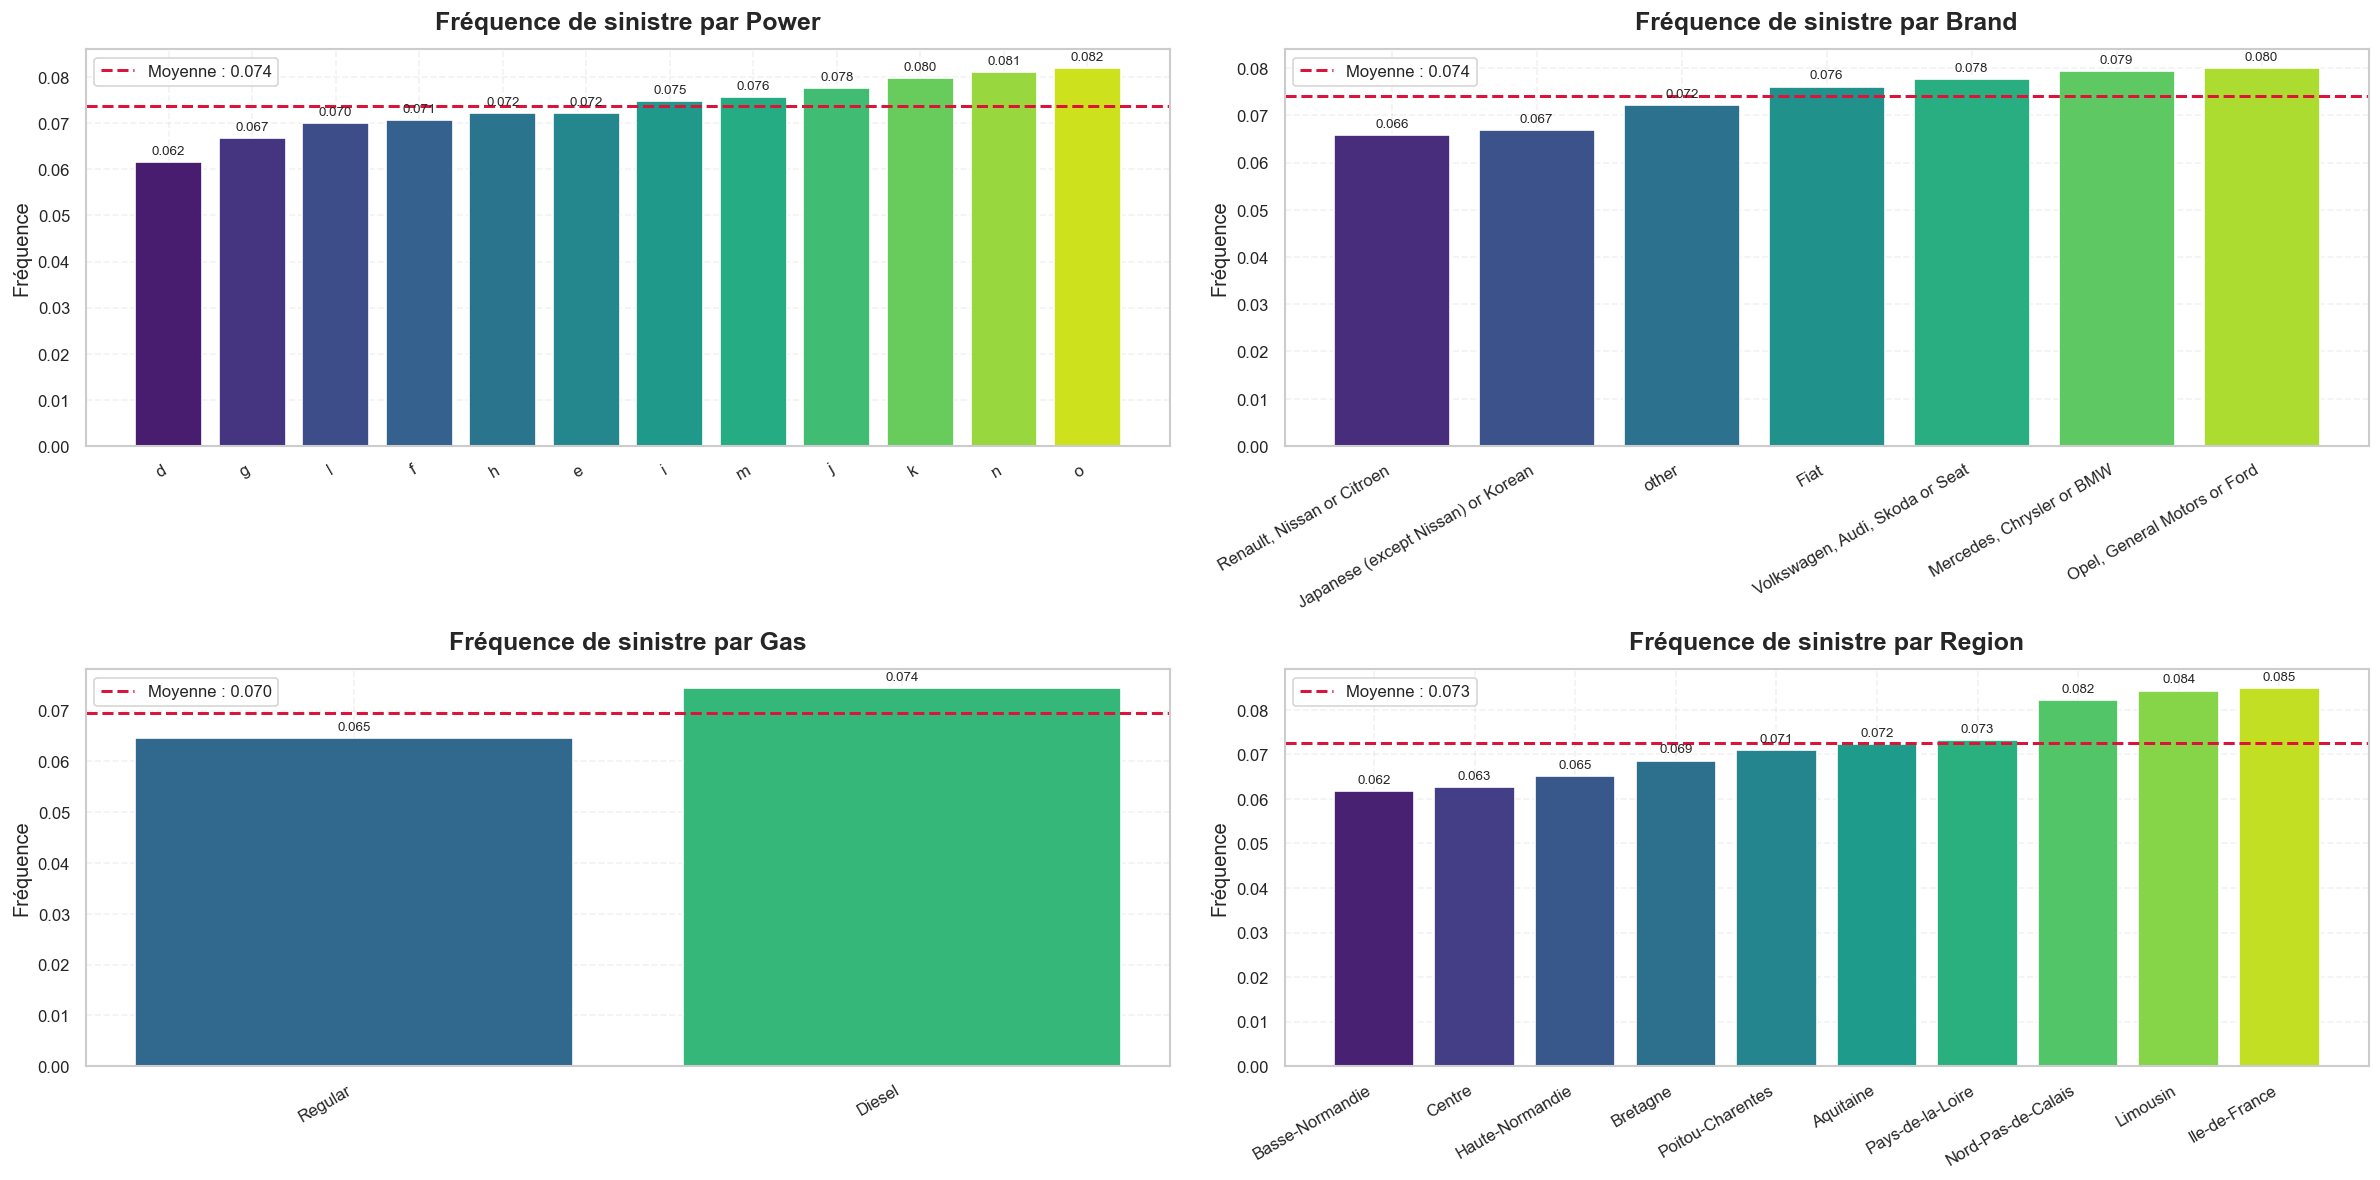

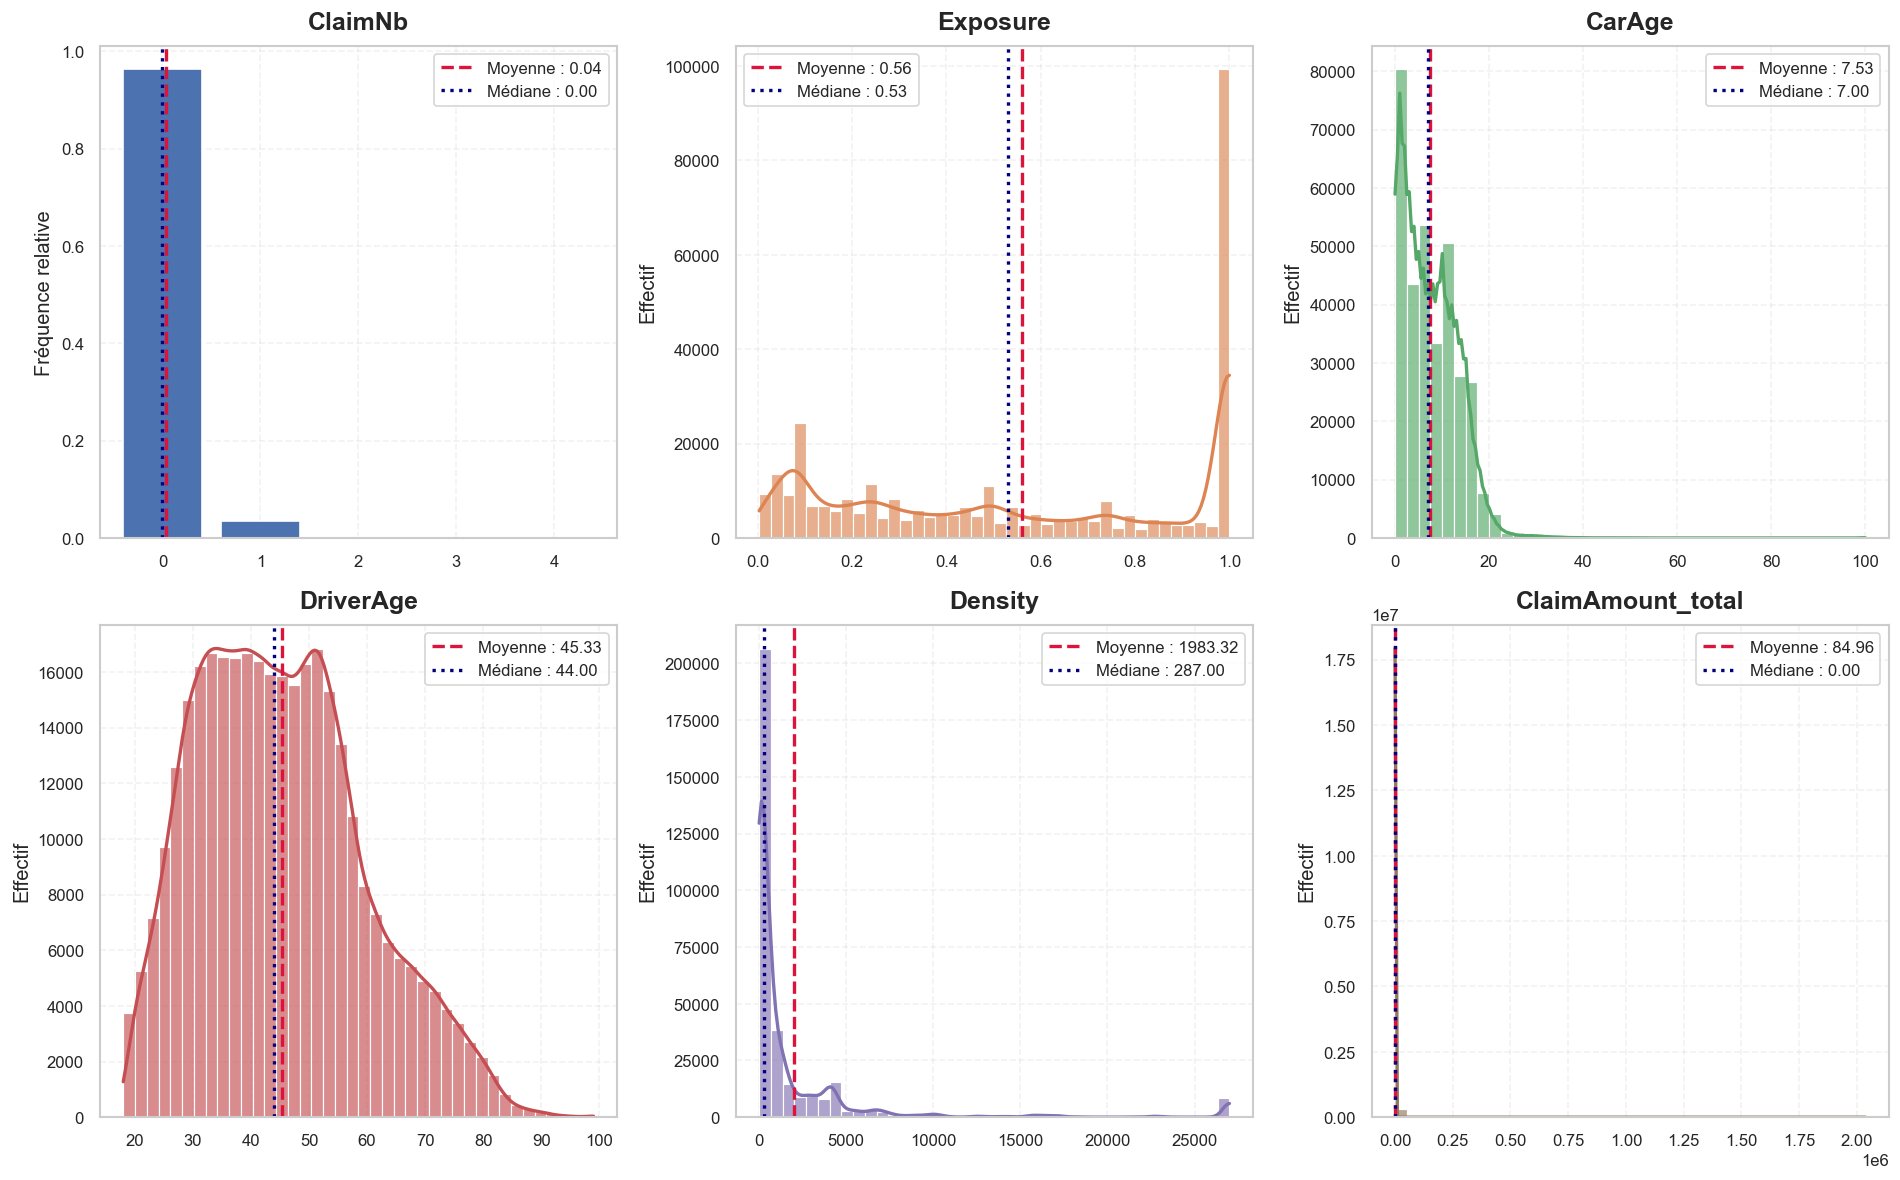

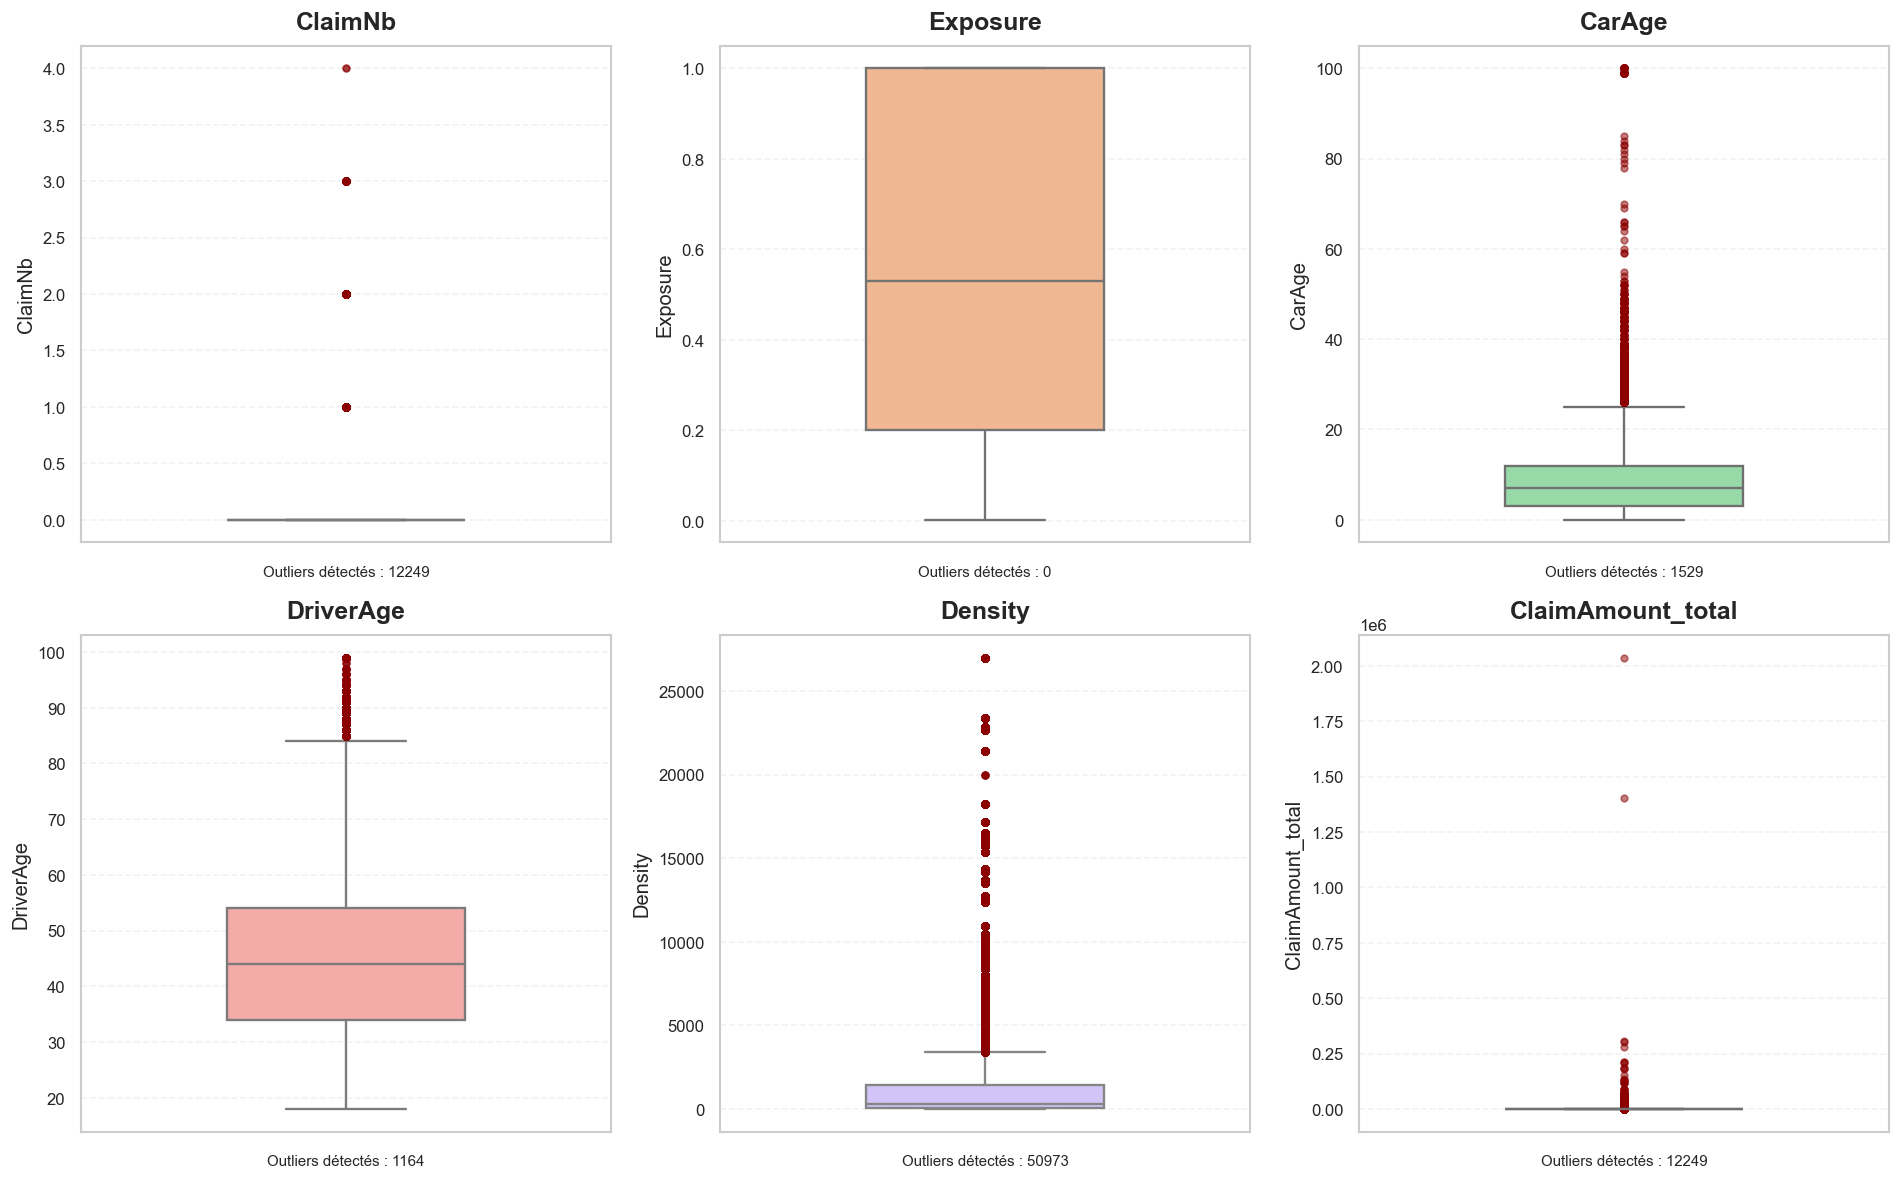

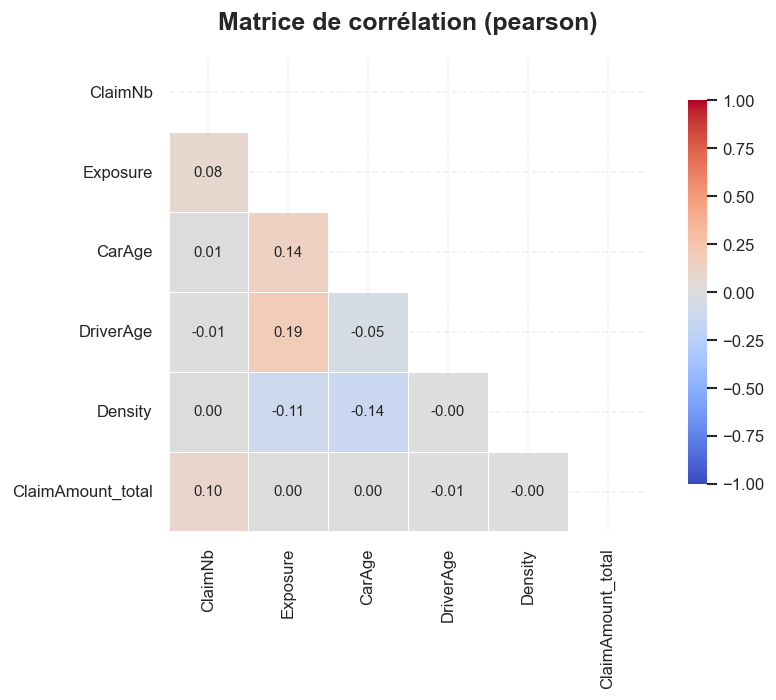

In [3]:
run_eda(
    split_data(data, data_sev)[0],
    qualitatives_var,
    quantitatives_var
)

# Preprocessing

In [4]:
train_freq, test_freq, train_sev, test_sev = (
    prepare_datasets(data, data_sev)
)

# Feature engineering

In [5]:
fe = FeatureEngineer()

train_freq = fe.fit_transform(train_freq)

test_freq = fe.transform(test_freq)

train_sev = fe.transform(train_sev)

test_sev = fe.transform(test_sev)

In [6]:
fe.get_discretization_summary()

,variable,classe,borne_inf,borne_sup
0,CarAge,CarAge_class_1,0.000000,7.000000
1,CarAge,CarAge_class_2,7.000000,100.000000
2,DriverAge,DriverAge_class_1,18.000000,32.000000
3,DriverAge,DriverAge_class_2,32.000000,40.000000
4,DriverAge,DriverAge_class_3,40.000000,48.000000
5,DriverAge,DriverAge_class_4,48.000000,57.000000
6,DriverAge,DriverAge_class_5,57.000000,99.000000
7,Density,Density_class_1,0.693147,3.931826
8,Density,Density_class_2,3.931826,5.062595
9,Density,Density_class_3,5.062595,6.309918


# Eda post-features engineering

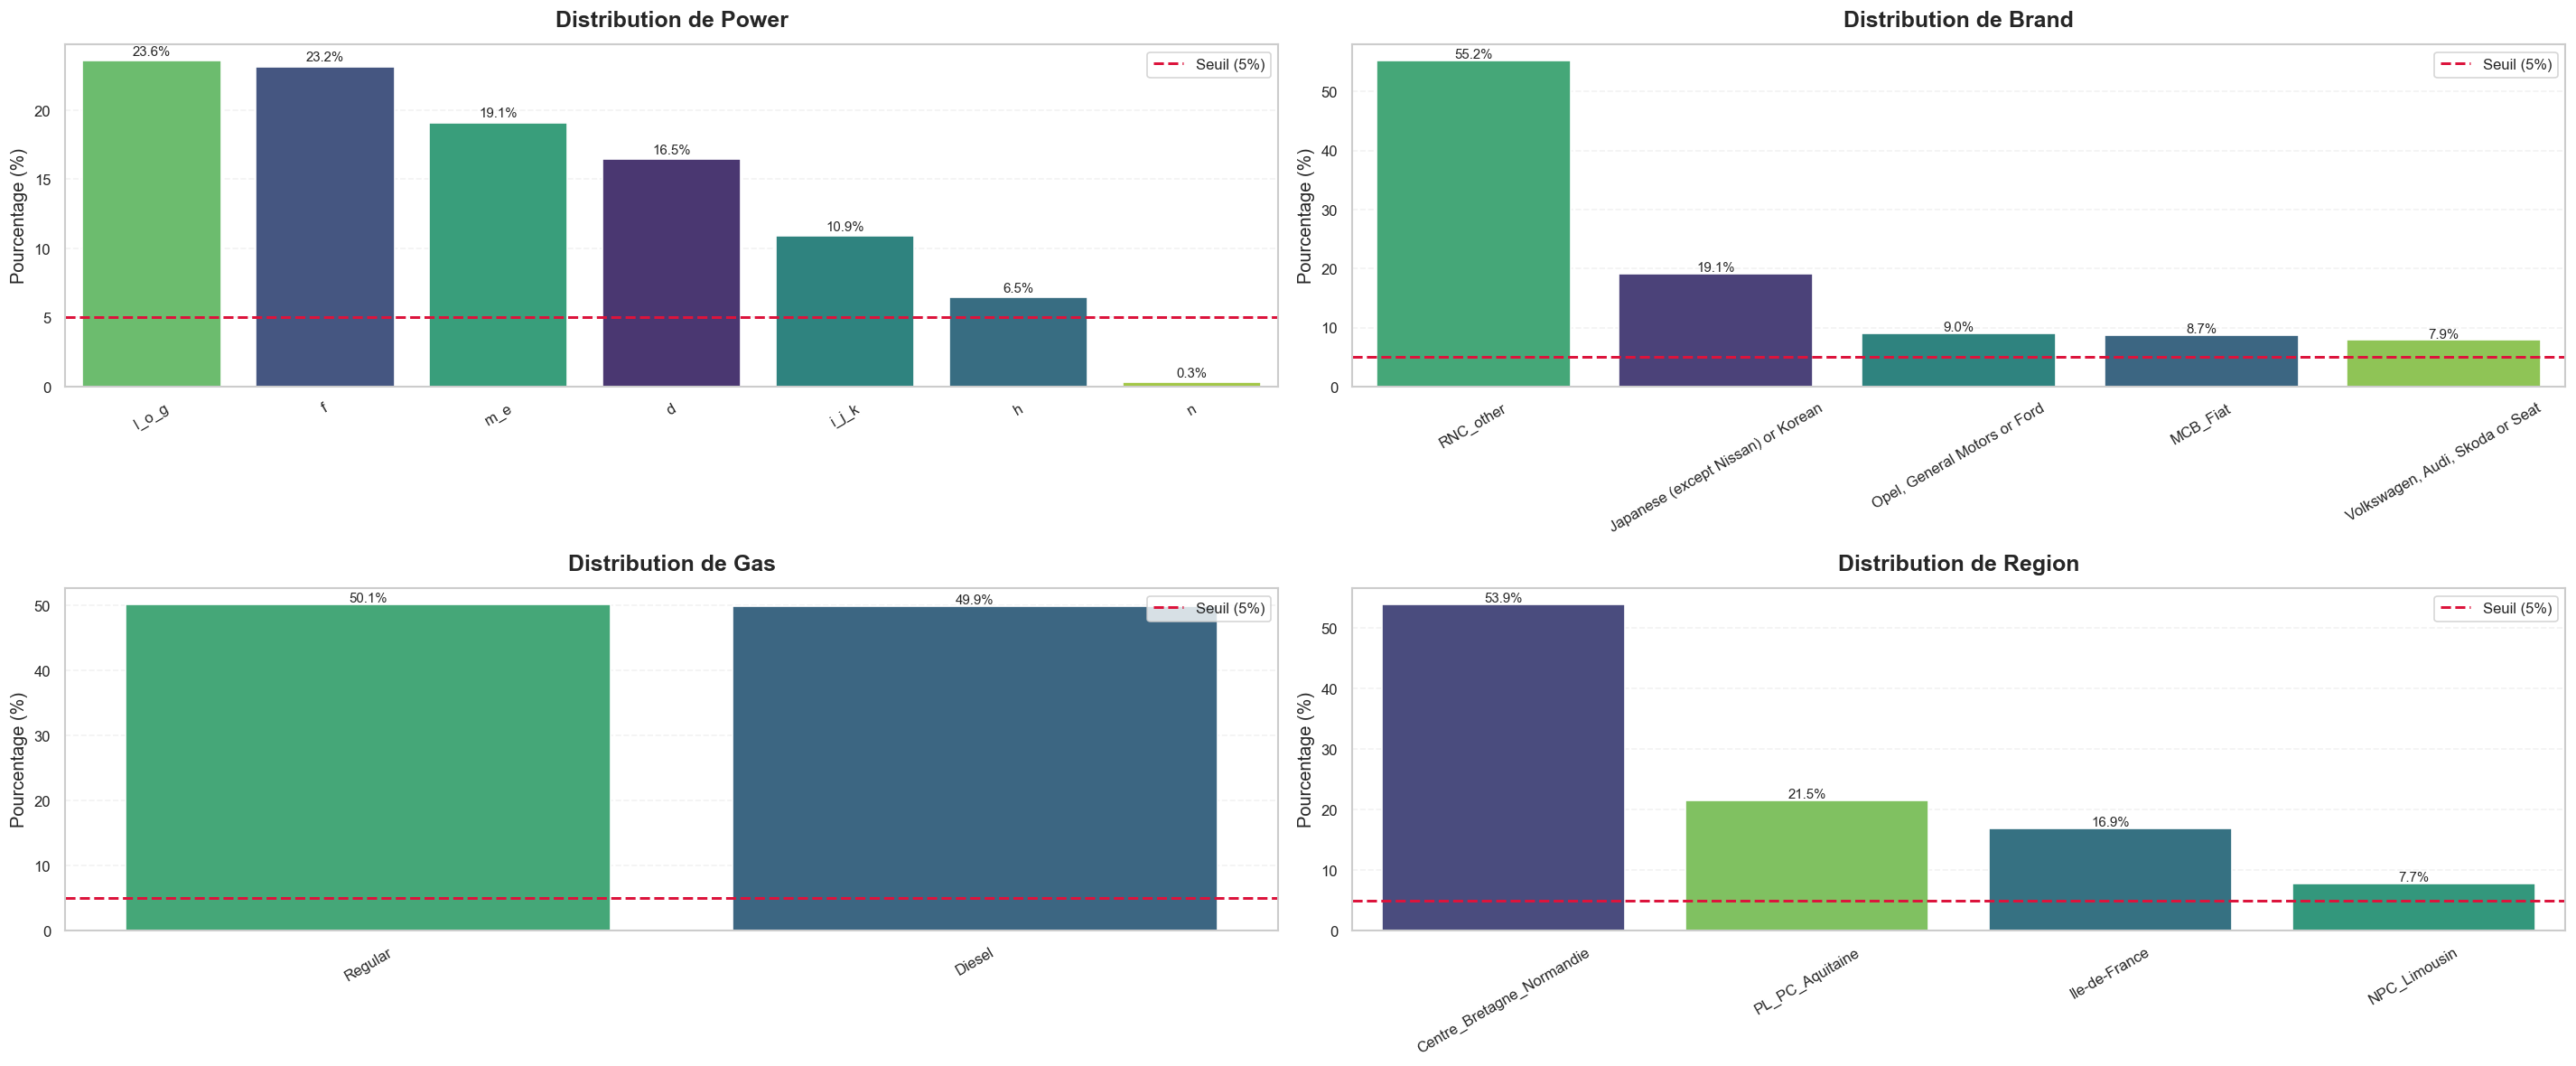

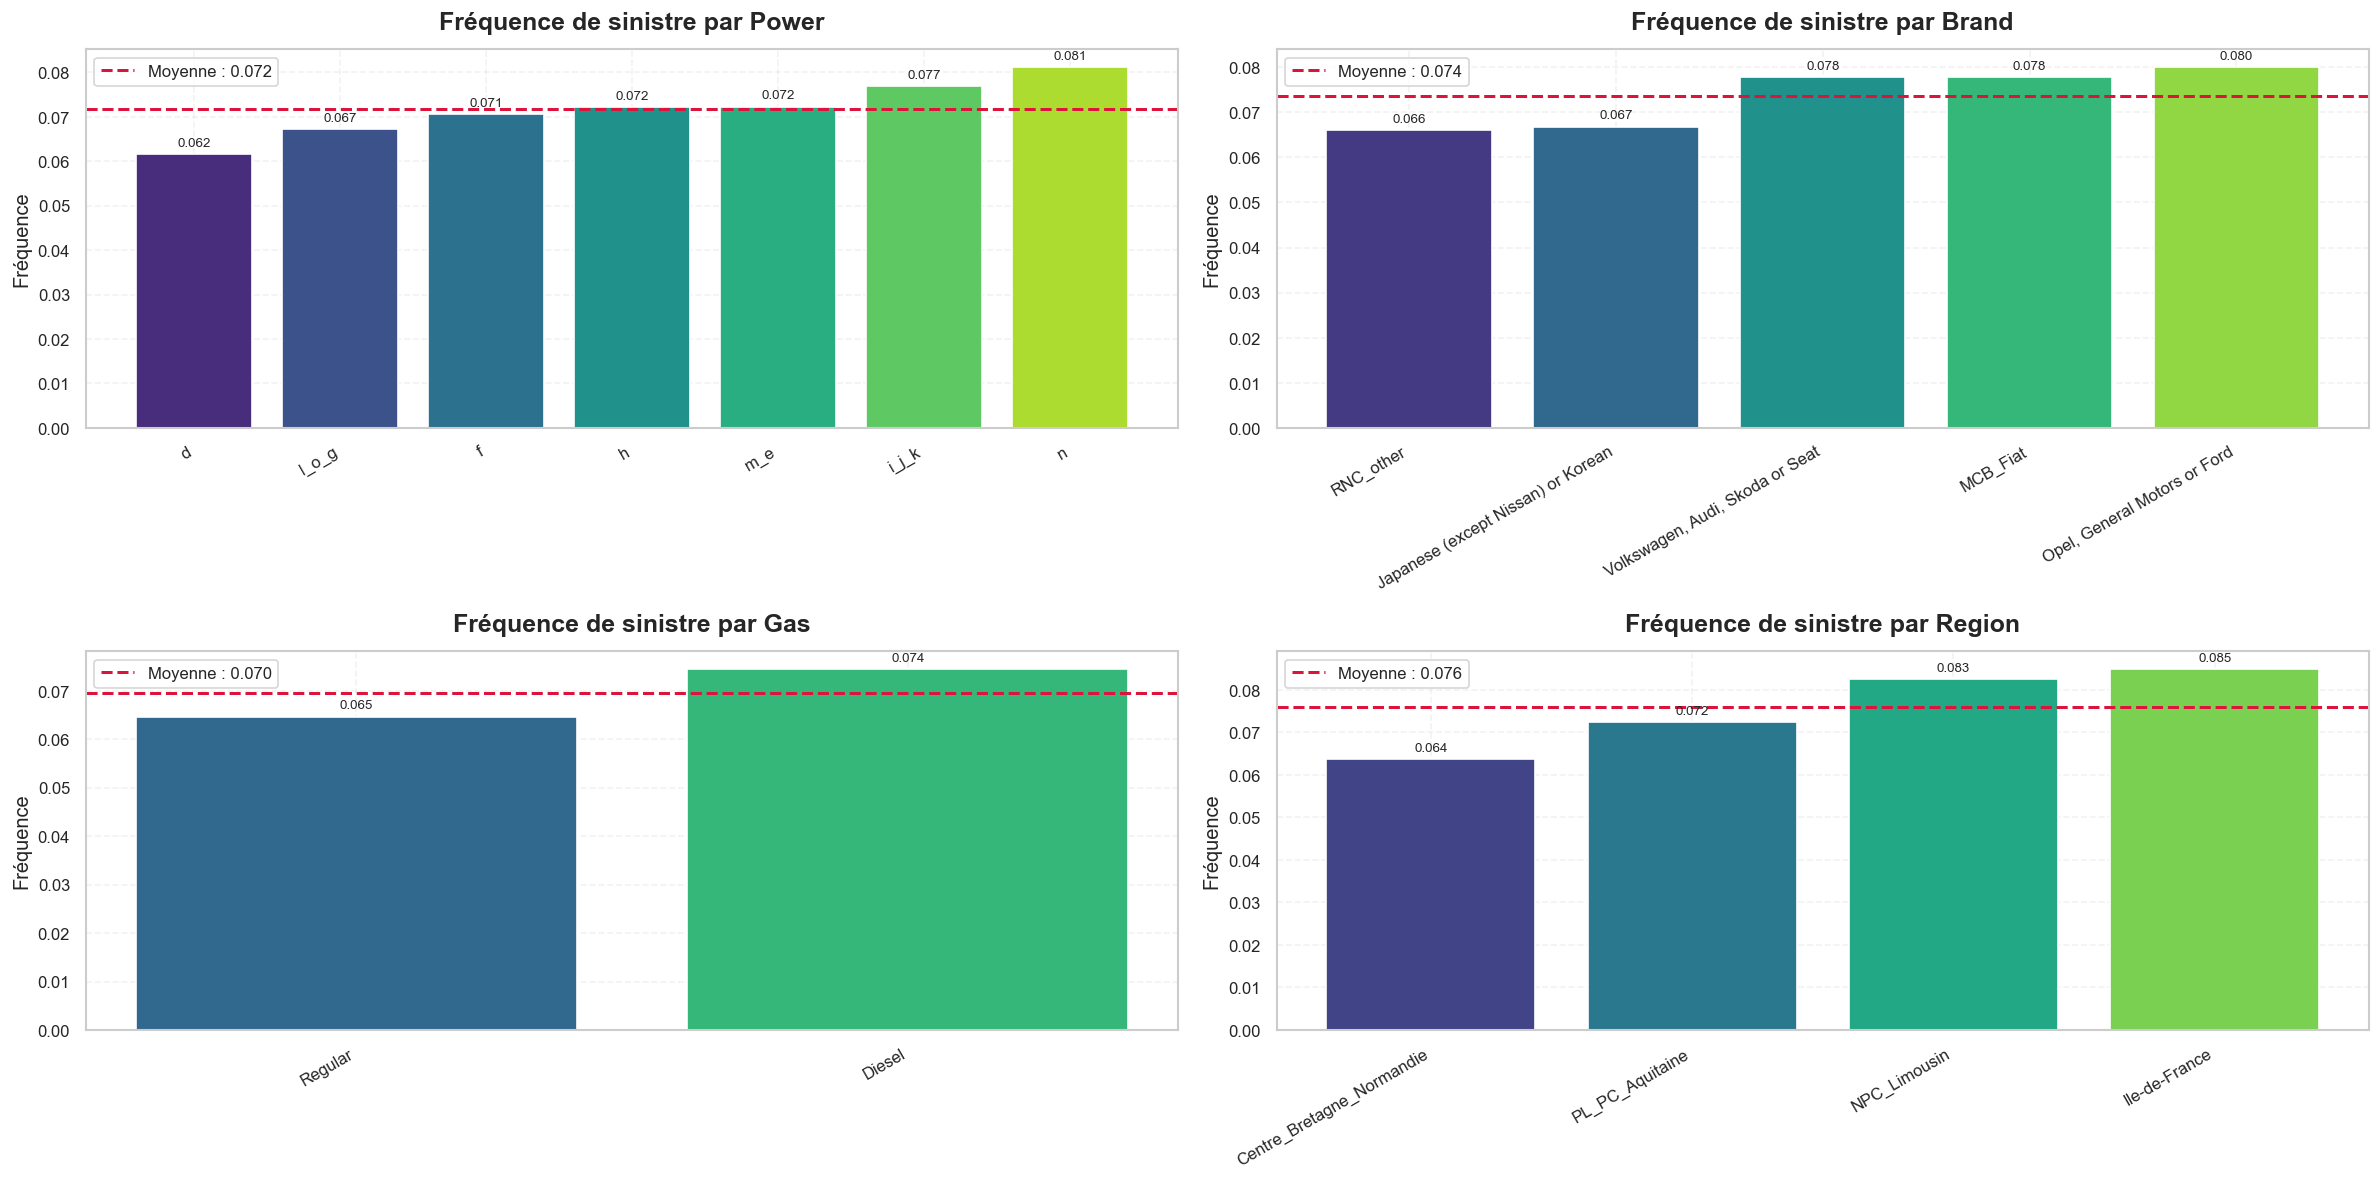

{'Power':        sinistres    exposition      freq
 Power                                   
 d           1865  30274.083744  0.061604
 l_o_g       2928  43608.239012  0.067143
 f           3159  44707.183219  0.070660
 h            802  11116.110870  0.072148
 m_e         2636  36481.813389  0.072255
 i_j_k       1431  18602.701240  0.076924
 n             44    542.329240  0.081132,
 'Brand':                                     sinistres     exposition      freq
 Brand                                                                 
 RNC_other                                7418  112282.936149  0.066065
 Japanese (except Nissan) or Korean       1665   24914.574899  0.066828
 Volkswagen, Audi, Skoda or Seat          1136   14613.949878  0.077734
 MCB_Fiat                                 1254   16120.264279  0.077790
 Opel, General Motors or Ford             1392   17400.735509  0.079997,
 'Gas':          sinistres    exposition      freq
 Gas                                       
 Re

In [7]:
plot_qualitative_distributions(
    train_freq,
    qualitatives_var,
    save = "_post_fe"
)

freq_exposition(
    train_freq,
    qualitatives_var,
    save = "_post_fe"
)

# Frequency model

In [8]:
freq_model = train_frequency_model(
    train_freq
)

freq_metrics = evaluate_frequency_model(
    freq_model,
    test_freq
)

# Severity model

In [9]:
sev_model, best_result = train_best_severity_model(
    train_sev
)

sev_metrics = evaluate_severity_model(
    sev_model,
    test_sev
)

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood ve

# Pure premium model

In [10]:
premium_data, premium_results = (
    build_premium_predictions(
        test_freq,
        freq_model,
        sev_model
    )
)

print(freq_metrics)
print(sev_metrics)
print(premium_results)

{'MAE': np.float64(0.0753), 'RMSE': np.float64(0.2065)}
{'MAE': np.float64(1944.1371), 'RMSE': np.float64(8431.6645)}
{'observed_cost': np.float64(6382638.0), 'predicted_premium': np.float64(6911910.59), 'sp_ratio': np.float64(0.9234), 'premium_metrics': {'MAE': np.float64(152.93), 'RMSE': np.float64(1693.22)}}


In [11]:
from pricing.tarif_coefficients import GLMCoefficients
from pricing.pricing_engine import PricingEngine
from pricing.relativities import compute_relativities

coeffs = GLMCoefficients(freq_model, sev_model)
engine = PricingEngine(coeffs)

VARIABLES = {
    "Power":           {"ref": "d",
                        "modalites": ["d", "f", "h", "i_j_k",
                                      "l_o_g", "m_e", "n"]},
    "Brand":           {"ref": "Japanese (except Nissan) or Korean",
                        "modalites": ["Japanese (except Nissan) or Korean",
                                      "MCB_Fiat",
                                      "Opel, General Motors or Ford",
                                      "RNC_other",
                                      "Volkswagen, Audi, Skoda or Seat"]},
    "Region":          {"ref": "Centre_Bretagne_Normandie",
                        "modalites": ["Centre_Bretagne_Normandie",
                                      "Ile-de-France",
                                      "NPC_Limousin",
                                      "PL_PC_Aquitaine"]},
    "DriverAge_class": {"ref": "DriverAge_class_1",
                        "modalites": ["DriverAge_class_1",
                                      "DriverAge_class_2",
                                      "DriverAge_class_3",
                                      "DriverAge_class_4",
                                      "DriverAge_class_5"]},
    "CarAge_class":    {"ref": "CarAge_class_1",
                        "modalites": ["CarAge_class_1",
                                      "CarAge_class_2"]},
    "Gas":             {"ref": "Diesel",
                        "modalites": ["Diesel", "Regular"]},
    "Density_class":   {"ref": "Density_class_1",
                        "modalites": ["Density_class_1",
                                      "Density_class_2",
                                      "Density_class_3",
                                      "Density_class_4",
                                      "Density_class_5"]},
}

In [12]:
rel_table = compute_relativities(coeffs, VARIABLES)

prime_ref = engine.reference_premium()

profile = {
    "Power": "d",
    "Brand": "MCB_Fiat",
    "Region": "Centre_Bretagne_Normandie",
    "DriverAge_class": "DriverAge_class_3",
    "CarAge_class": "CarAge_class_1",
    "Gas": "Diesel",
    "Density_class": "Density_class_2"
}

print(f"Prime de référence : {prime_ref:.2f}")
print(f"Prime pure : {engine.pure_premium(profile)}")
print(f"Tableau de relativities : {rel_table}")

Prime de référence : 188.06
Prime pure : {'freq': np.float64(0.06698142713665929), 'sev': np.float64(1439.146696292323), 'premium': np.float64(96.39609957666816)}
Tableau de relativities :            Variable                            Modalité  Référence  Rel_Freq  \
0             Power                                   d       True  1.000000   
1             Power                                   f      False  1.106128   
2             Power                                   h      False  1.132292   
3             Power                               i_j_k      False  1.242863   
4             Power                               l_o_g      False  1.083724   
5             Power                                 m_e      False  1.102212   
6             Power                                   n      False  1.265822   
7             Brand  Japanese (except Nissan) or Korean       True  1.000000   
8             Brand                            MCB_Fiat      False  1.298636   
9          

In [13]:
fixed_profile = {
    "Power": "d",
    "Brand": "Japanese (except Nissan) or Korean",
    "Region": "Centre_Bretagne_Normandie",
    "DriverAge_class": "DriverAge_class_3",
    "CarAge_class": "CarAge_class_1",
    "Gas": "Diesel",
    "Density_class": "Density_class_3"
}

powers = VARIABLES["Power"]["modalites"]
brands = VARIABLES["Brand"]["modalites"]

from pricing.tarif_grid import build_grid
grid = build_grid(engine, "Power", "Brand", fixed_profile, powers, brands)

print(grid)

       Japanese (except Nissan) or Korean  MCB_Fiat  \
d                                  109.69    102.68   
f                                  168.24    157.48   
h                                  136.16    127.44   
i_j_k                              222.01    207.81   
l_o_g                              137.55    128.75   
m_e                                123.07    115.20   
n                                  168.02    157.27   

       Opel, General Motors or Ford  RNC_other  \
d                             99.90     109.77   
f                            153.23     168.36   
h                            124.01     136.25   
i_j_k                        202.20     222.17   
l_o_g                        125.27     137.64   
m_e                          112.09     123.16   
n                            153.02     168.14   

       Volkswagen, Audi, Skoda or Seat  
d                               116.99  
f                               179.44  
h                               145

In [14]:
from models.large_claims_model import run_large_claims_pipeline, compute_tariff_with_large_claim_loading
from visualization.large_claims_plots import (
    plot_mean_excess_function,
    plot_premium_decomposition
)
from models.premium_model import compute_sp_ratio, compute_observed_cost

RÉSULTATS LARGE CLAIMS
Seuil M1 : 40,107 €
P(atypique) : 0.4819%
E[excédent | atypique] : 108,716.10 €
PRIME PURE DEUX COMPOSANTES
count    82634.000000
mean        85.251461
std         59.798495
min          0.204379
25%         30.812207
50%         83.468467
75%        127.342564
max        440.554118
Name: pure_premium_2comp, dtype: float64
PRIME AVEC LOADING
count    82634.000000
mean       104.107091
std         79.191610
min          0.228300
25%         35.899385
50%         97.447939
75%        150.696463
max        593.342369
Name: pure_premium_loaded, dtype: float64
COMPARAISON
pure_premium        83.644875
premium_loading    104.107091
premium_2comp       85.251461
dtype: float64


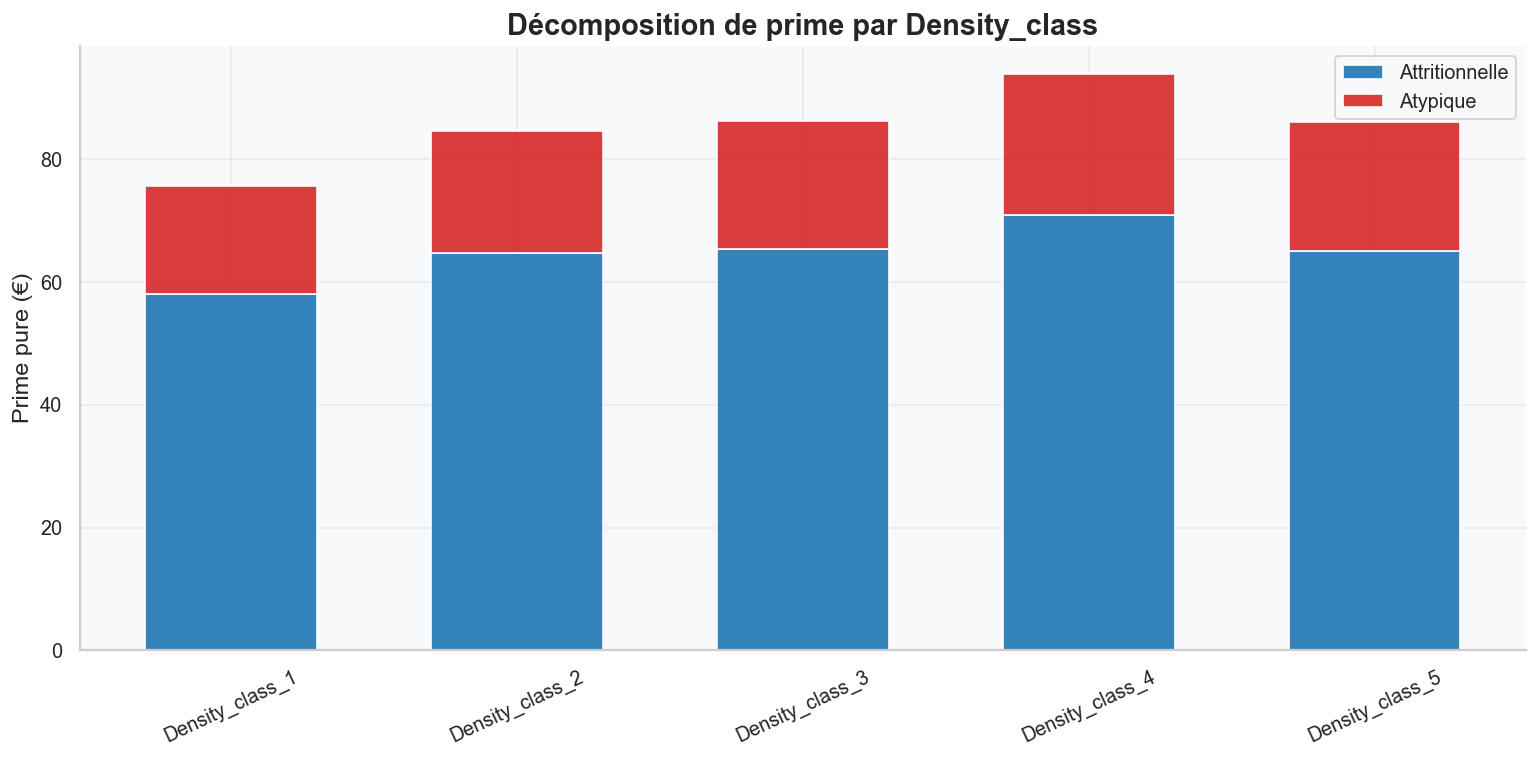

EXPORT TERMINÉ
premium_comparison.csv
SP Ratio 2 composantes : 0.9060
SP Ratio loading : 0.7419


In [15]:
# MODÈLE GROS SINISTRES
# NB : le pipeline force la cible du GLM attritionnel à
# severity_capped (sévérité écrêtée au seuil M1) ; seule la
# partie droite de la formule (les variables) est utilisée.
large_claims_results = run_large_claims_pipeline(
    train_sev=train_sev,
    test_freq=premium_data,
    formula="""
        severity_capped ~
        C(Power)
        + C(Brand)
        + C(Region)
        + C(DriverAge_class)
        + C(CarAge_class)
        + C(Gas)
        + C(Density_class)
    """,
    claim_amount_col="ClaimAmount_total",
    quantile=0.995
)

print("RÉSULTATS LARGE CLAIMS")
print(
    f"Seuil M1 : "
    f"{large_claims_results['threshold_info']['threshold']:,.0f} €"
)

print(
    f"P(atypique) : "
    f"{large_claims_results['loading_info']['p_large']:.4%}"
)

print(
    f"E[excédent | atypique] : "
    f"{large_claims_results['loading_info']['mean_excess']:,.2f} €"
)



# PRIME DEUX COMPOSANTES
test_freq_2comp = large_claims_results["test_predictions"].copy()

print("PRIME PURE DEUX COMPOSANTES")
print(
    test_freq_2comp[
        "pure_premium_2comp"
    ].describe()
)


# APPROCHE LOADING SIMPLE
# Chargement atypique unitaire = P(atypique) × E[excédent | atypique],
# appliqué à la prime pure standard (sans écrêtement).
# Attention : cette approche double-compte partiellement les gros
# sinistres (la sévérité standard n'est pas écrêtée) — elle est
# conservée à titre de comparaison avec l'approche deux composantes.
loading_per_claim = (
    large_claims_results["loading_info"]["p_large"]
    * large_claims_results["loading_info"]["mean_excess"]
)

test_freq_loaded = (
    compute_tariff_with_large_claim_loading(
        data=premium_data,
        base_premium_col="pure_premium",
        frequency_col="freq_pred",
        loading_per_claim=loading_per_claim
    )
)

print("PRIME AVEC LOADING")
print(
    test_freq_loaded[
        "pure_premium_loaded"
    ].describe()
)


# COMPARAISON DES APPROCHES
comparison = (
    premium_data[
        ["pure_premium"]
    ]
    .copy()
)

comparison["premium_loading"] = (
    test_freq_loaded[
        "pure_premium_loaded"
    ]
)

comparison["premium_2comp"] = (
    test_freq_2comp[
        "pure_premium_2comp"
    ]
)

print("COMPARAISON")
print(
    comparison.mean()
)


#VISUALISATIONS
plot_premium_decomposition(
    data=test_freq_2comp,
    group_col="Density_class",
)


# EXPORT
comparison.to_csv(
    "premium_comparison.csv",
    index=False
)


print("EXPORT TERMINÉ")
print("premium_comparison.csv")

observed_cost_2comp = compute_observed_cost(
    data=test_freq_2comp)
sp_ratio_2comp = compute_sp_ratio(
    observed_cost=observed_cost_2comp, 
    predicted_premium=test_freq_2comp["pure_premium_2comp"].sum()
    )

observed_cost_loaded = compute_observed_cost(
    data=test_freq_loaded)
sp_ratio_loaded = compute_sp_ratio(
    observed_cost=observed_cost_loaded, 
    predicted_premium=test_freq_loaded["pure_premium_loaded"].sum()
    )

print(f"SP Ratio 2 composantes : {sp_ratio_2comp:.4f}")
print(f"SP Ratio loading : {sp_ratio_loaded:.4f}")

In [16]:
large_claims_results.keys()

dict_keys(['threshold_info', 'attritional_claims', 'large_claims', 'train_capped', 'severity_model', 'loading_info', 'test_predictions'])

In [17]:
from visualization.large_claims_plots import run_large_claims_report

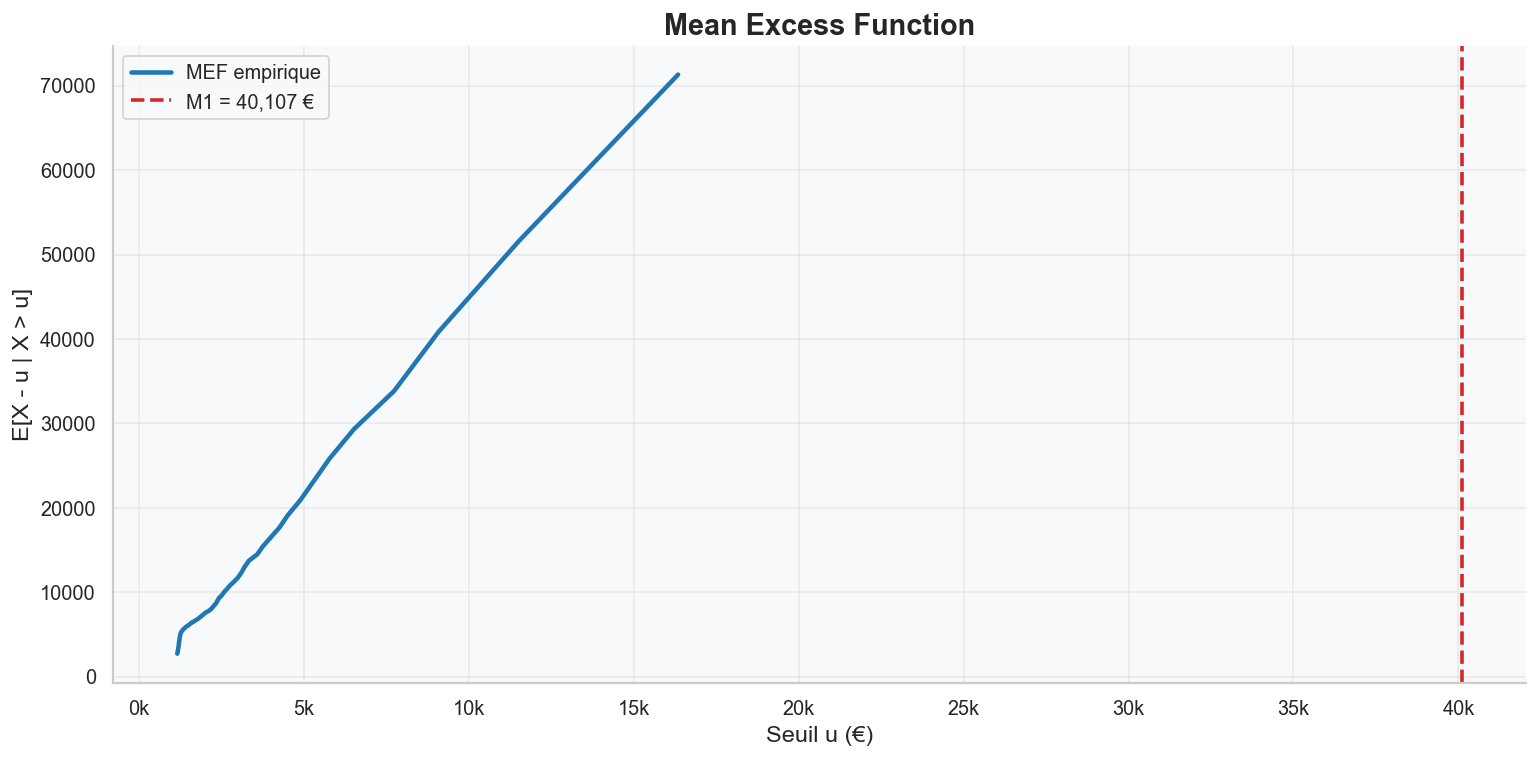

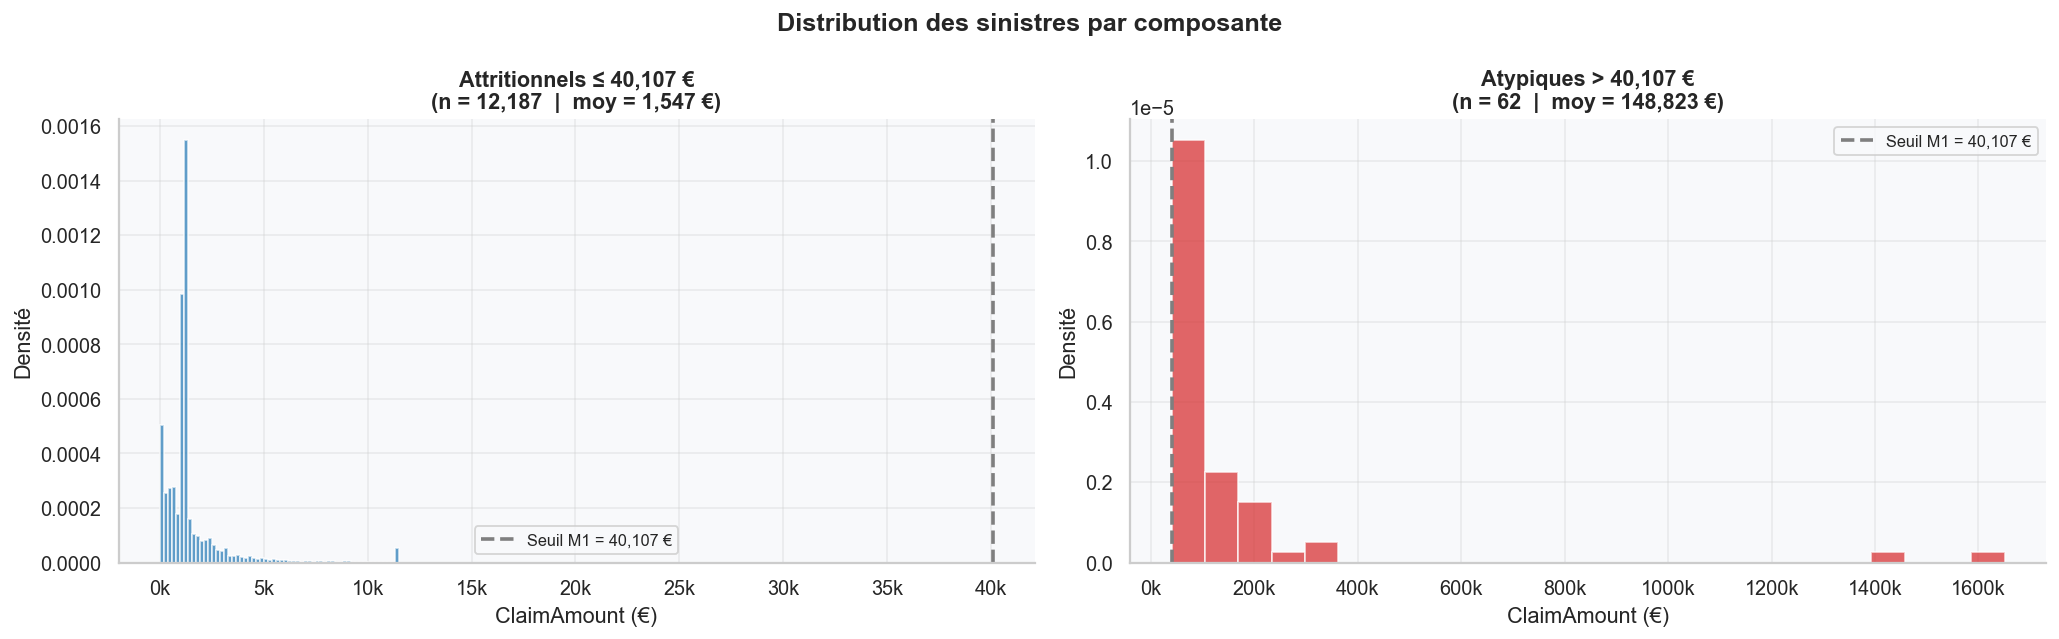

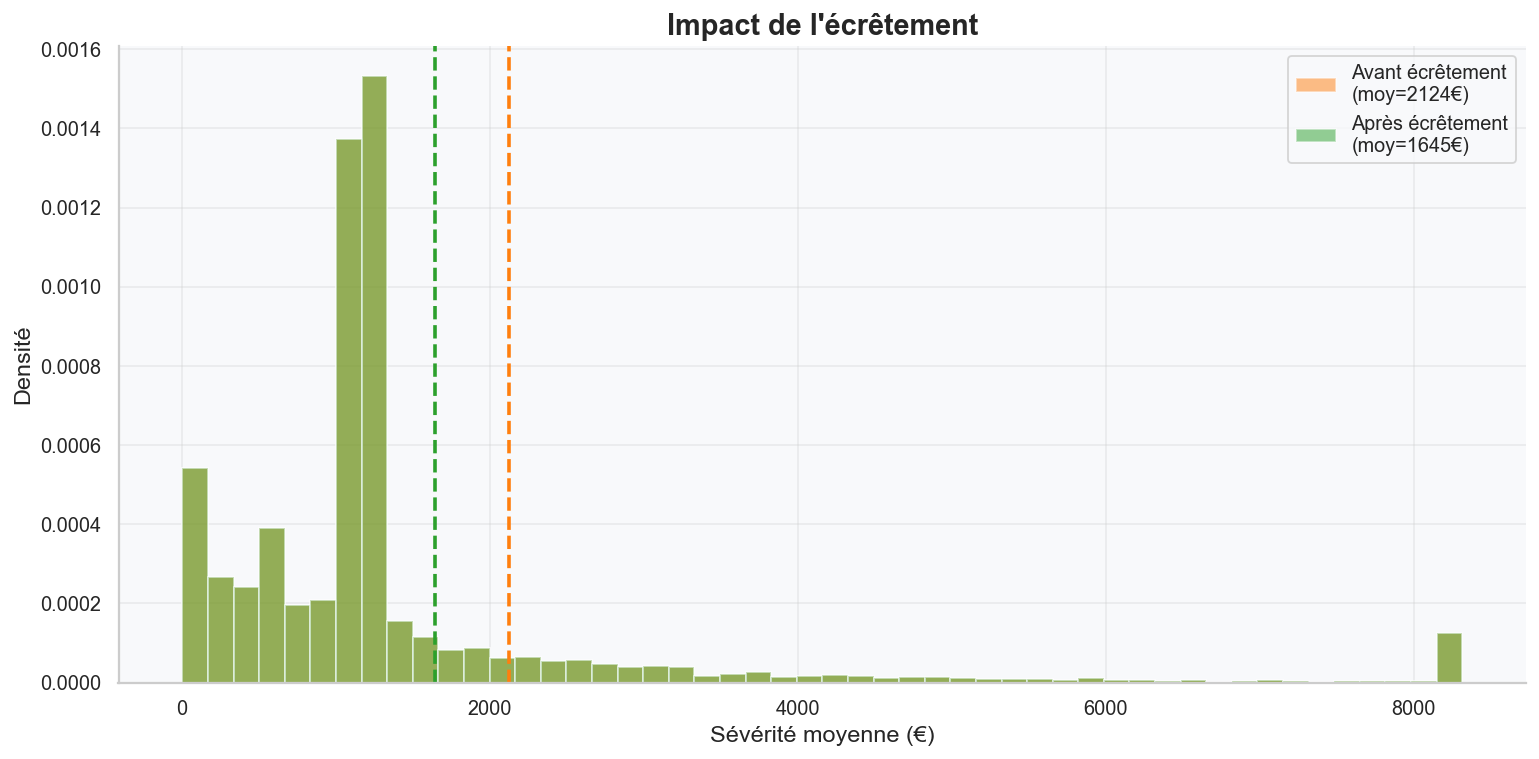

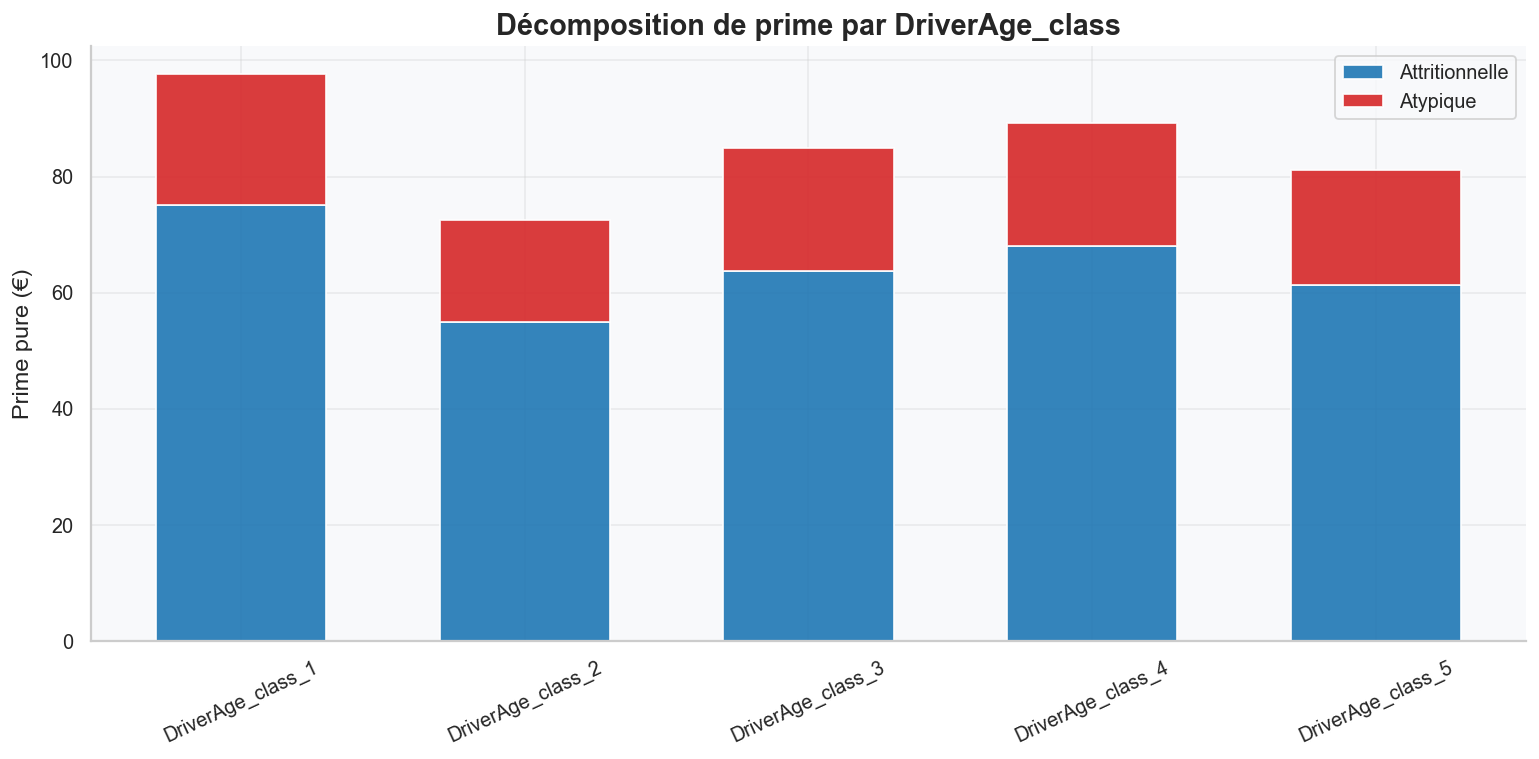

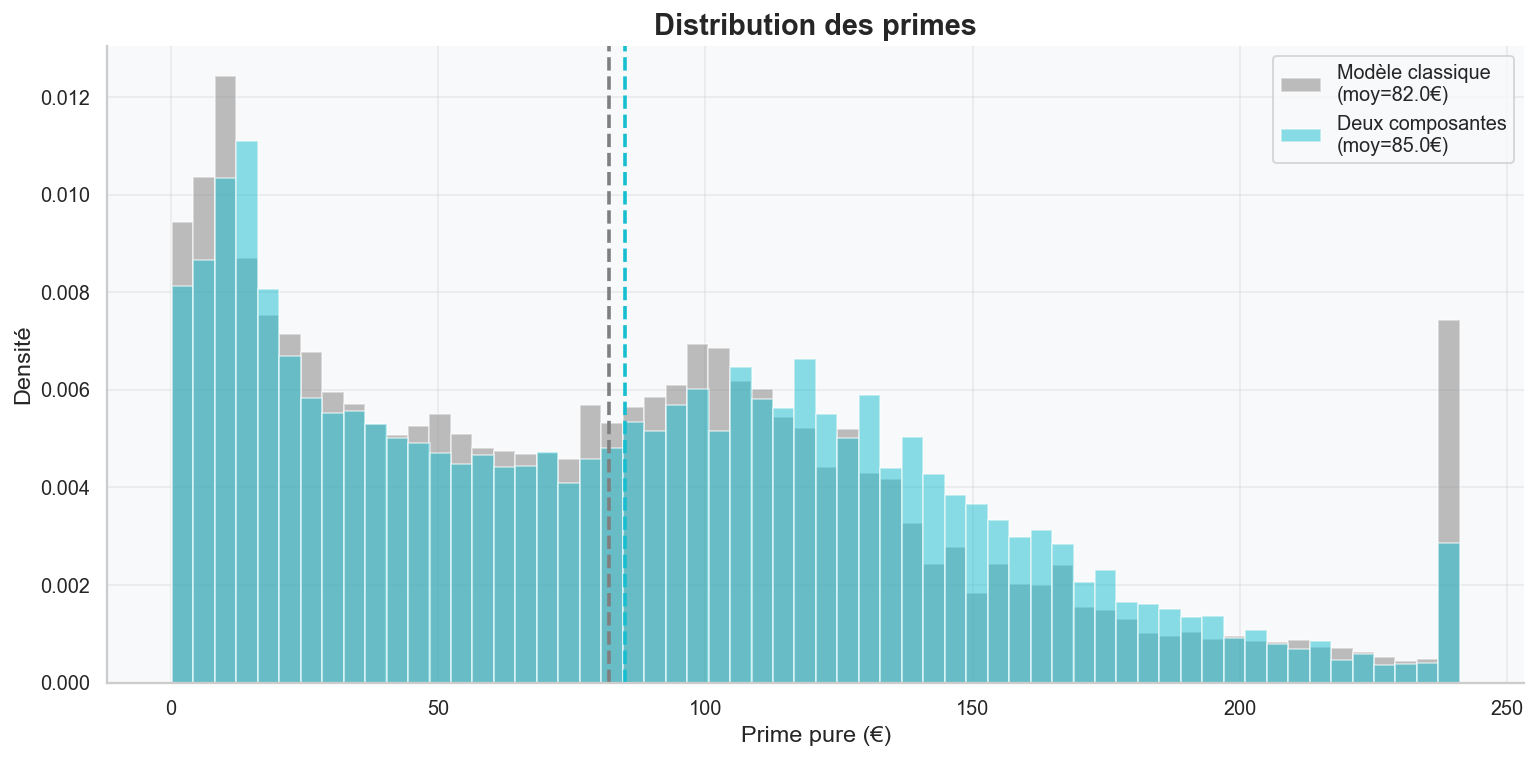

In [18]:
run_large_claims_report(
    train_sev=large_claims_results["train_capped"],
    test_freq=test_freq_2comp,
    threshold_info=large_claims_results["threshold_info"],
    claim_amount="ClaimAmount_total"
)

# ML

In [19]:
from data.preprocessing import split_data
from features.ml_features_engineer import MLFeatureEngineer

In [20]:
ml_train_freq, ml_test_freq, ml_train_sev, ml_test_sev = split_data(data, data_sev)

ml_fe = MLFeatureEngineer()
ml_train_freq = ml_fe.fit_transform(ml_train_freq)
ml_test_freq = ml_fe.transform(ml_test_freq)
ml_train_sev = ml_fe.transform(ml_train_sev)
ml_test_sev = ml_fe.transform(ml_test_sev)

In [21]:
FEATURES = ml_train_freq.drop(
    columns=["ClaimAmount_total", "Exposure", "ClaimNb", "PolicyID"]
    ).columns.tolist()

FEATURES

['Power',
 'CarAge',
 'DriverAge',
 'Brand',
 'Gas',
 'Region',
 'Density',
 'log_Density']

In [22]:
cat_features = ml_train_freq.select_dtypes(
    include=["object", "category"]
    ).columns.tolist()

for col in cat_features:
    ml_train_freq[col] = (
        ml_train_freq[col]
        .astype("category")
    )

    ml_test_freq[col] = (
        ml_test_freq[col]
        .astype("category")
    )

    ml_train_sev[col] = (
        ml_train_sev[col]
        .astype("category")
    )

    ml_test_sev[col] = (
        ml_test_sev[col]
        .astype("category")
    )
cat_features

['Power', 'Brand', 'Gas', 'Region']

In [23]:
from sklearn.model_selection import train_test_split
from models.ml_frequency_model import LGBFrequencyModel

# Jeu de validation pour l'early stopping :
# le nombre d'arbres est choisi par les données,
# pas fixé a priori.
ml_tr_freq, ml_val_freq = train_test_split(
    ml_train_freq, test_size=0.2, random_state=42
)

# Contrainte de monotonie actuarielle :
# la fréquence de sinistre croît avec la densité de
# population (évite les inversions locales indéfendables).
MONOTONE_CONSTRAINTS = {"Density": +1, "log_Density": +1}

ml_freq_model = LGBFrequencyModel(
    monotone_constraints=MONOTONE_CONSTRAINTS
)

ml_freq_model.fit(
    ml_tr_freq[FEATURES],
    ml_tr_freq["ClaimNb"],
    ml_tr_freq["Exposure"],
    X_val=ml_val_freq[FEATURES],
    y_val=ml_val_freq["ClaimNb"],
    exposure_val=ml_val_freq["Exposure"],
)

print(
    f"Arbres retenus (early stopping) : "
    f"{ml_freq_model.model.best_iteration_}"
)

Arbres retenus (early stopping) : 235


In [24]:
from models.large_claims_model import prepare_severity_capping
from models.ml_severity_model import LGBSeverityModel

# Écrêtement : même méthodologie que le pipeline GLM.
# Un GBM ne peut pas apprendre la queue de distribution
# sur quelques dizaines de sinistres extrêmes : on
# entraîne sur la sévérité écrêtée et l'excédent est
# tarifé via un chargement.
capping_ml = prepare_severity_capping(
    ml_train_sev,
    quantile=0.995,
    claim_amount_col="ClaimAmount_total"
)

ml_train_sev_capped = capping_ml["train_capped"]

print(
    f"Seuil M1 : {capping_ml['threshold']:,.0f} € | "
    f"P(atypique) : {capping_ml['p_large']:.4%} | "
    f"chargement/sinistre : "
    f"{capping_ml['loading_per_claim']:.2f} €"
)

ml_tr_sev, ml_val_sev = train_test_split(
    ml_train_sev_capped, test_size=0.2, random_state=42
)

ml_sev_model = LGBSeverityModel()

ml_sev_model.fit(
    ml_tr_sev[FEATURES],
    ml_tr_sev["severity_capped"],
    claim_nb=ml_tr_sev["ClaimNb"],
    X_val=ml_val_sev[FEATURES],
    y_val=ml_val_sev["severity_capped"],
    claim_nb_val=ml_val_sev["ClaimNb"],
)

print(
    f"Arbres retenus (early stopping) : "
    f"{ml_sev_model.model.best_iteration_}"
)

Seuil M1 : 40,107 € | P(atypique) : 0.4819% | chargement/sinistre : 523.93 €
Arbres retenus (early stopping) : 3


In [25]:
from models.ml_evaluate import compute_rebalancing_factor

# Prime pure ML = fréquence attendue × (sévérité écrêtée + chargement)
loading_ml = capping_ml["loading_per_claim"]

def ml_pure_premium(df):
    freq_pred = (
        ml_freq_model.predict(df[FEATURES]) * df["Exposure"]
    )
    sev_capped_pred = ml_sev_model.predict(df[FEATURES])
    return freq_pred * (sev_capped_pred + loading_ml)

# Recalage global : contrairement au GLM Poisson, un GBM
# ne garantit pas l'équilibre agrégé — on force S/P = 1
# sur le train par un facteur multiplicatif unique.
factor_ml = compute_rebalancing_factor(
    ml_train_freq["ClaimAmount_total"].sum(),
    ml_pure_premium(ml_train_freq).sum()
)
print(f"Facteur de recalage ML : {factor_ml:.4f}")

ml_test_freq["pure_premium_ml"] = (
    ml_pure_premium(ml_test_freq) * factor_ml
)

ml_test_freq["freq_pred_ml"] = (
    ml_freq_model.predict(ml_test_freq[FEATURES])
    * ml_test_freq["Exposure"]
)

Facteur de recalage ML : 1.0003


# Modèle Tweedie direct

Alternative à la décomposition fréquence × sévérité : un seul modèle sur la charge annuelle par police (loi Tweedie = Poisson composé Gamma, variance power ∈ (1, 2)). Il apprend sur **tout** le portefeuille (413k polices, y compris les non-sinistrées) au lieu de 12k polices sinistrées pour la sévérité.

In [26]:
from models.ml_tweedie_model import LGBTweedieModel

tweedie_model = LGBTweedieModel(
    tweedie_variance_power=1.5,
    monotone_constraints=MONOTONE_CONSTRAINTS
)

tweedie_model.fit(
    ml_tr_freq[FEATURES],
    ml_tr_freq["ClaimAmount_total"],
    ml_tr_freq["Exposure"],
    X_val=ml_val_freq[FEATURES],
    claim_amount_val=ml_val_freq["ClaimAmount_total"],
    exposure_val=ml_val_freq["Exposure"],
)

print(
    f"Arbres retenus (early stopping) : "
    f"{tweedie_model.model.best_iteration_}"
)

# Recalage S/P = 1 sur le train
premium_train_tw = (
    tweedie_model.predict(ml_train_freq[FEATURES])
    * ml_train_freq["Exposure"]
)

factor_tw = compute_rebalancing_factor(
    ml_train_freq["ClaimAmount_total"].sum(),
    premium_train_tw.sum()
)
print(f"Facteur de recalage Tweedie : {factor_tw:.4f}")

ml_test_freq["pure_premium_tweedie"] = (
    tweedie_model.predict(ml_test_freq[FEATURES])
    * ml_test_freq["Exposure"]
    * factor_tw
)

Arbres retenus (early stopping) : 153
Facteur de recalage Tweedie : 1.2930


In [27]:
import pandas as pd
from models.ml_evaluate import model_report, lift_table

# Alignement GLM / ML par PolicyID : mêmes polices de test,
# mais les datasets diffèrent par le feature engineering.
glm_test = test_freq_2comp[
    ["PolicyID", "freq_pred", "pure_premium", "pure_premium_2comp"]
].rename(columns={"freq_pred": "freq_pred_glm"})

eval_df = ml_test_freq.merge(glm_test, on="PolicyID", how="inner")
print(f"Polices de test alignées : {len(eval_df):,}\n")

report = pd.DataFrame([
    model_report(
        "GLM freq x sev",
        eval_df["ClaimNb"], eval_df["freq_pred_glm"],
        eval_df["pure_premium"], eval_df["ClaimAmount_total"]
    ),
    model_report(
        "GLM 2 composantes",
        eval_df["ClaimNb"], eval_df["freq_pred_glm"],
        eval_df["pure_premium_2comp"], eval_df["ClaimAmount_total"]
    ),
    model_report(
        "ML freq x sev (écrêté, recalé)",
        eval_df["ClaimNb"], eval_df["freq_pred_ml"],
        eval_df["pure_premium_ml"], eval_df["ClaimAmount_total"]
    ),
    model_report(
        "Tweedie direct (recalé)",
        eval_df["ClaimNb"], None,
        eval_df["pure_premium_tweedie"], eval_df["ClaimAmount_total"]
    ),
])

print(report.to_string(index=False))

print("\nLift ML freq x sev (par décile de prime prédite) :")
print(
    lift_table(
        eval_df["ClaimAmount_total"], eval_df["pure_premium_ml"]
    ).to_string(index=False)
)

print("\nLift Tweedie :")
print(
    lift_table(
        eval_df["ClaimAmount_total"], eval_df["pure_premium_tweedie"]
    ).to_string(index=False)
)

Polices de test alignées : 82,634

                         model  poisson_deviance   gini  sp_ratio
                GLM freq x sev           0.25818 0.1911    0.9234
             GLM 2 composantes           0.25818 0.1803    0.9060
ML freq x sev (écrêté, recalé)           0.25663 0.1830    0.9069
       Tweedie direct (recalé)               NaN 0.1743    0.9126

Lift ML freq x sev (par décile de prime prédite) :
bin    n  pred_mean   obs_mean  ratio_obs_pred
  1 8264   5.882813  35.359874        6.010708
  2 8263  15.692969  42.989713        2.739425
  3 8263  30.271390  41.351204        1.366016
  4 8264  49.019226  98.405252        2.007483
  5 8263  70.319402  77.304006        1.099327
  6 8263  91.233734  63.843035        0.699774
  7 8264 109.396119  84.815344        0.775305
  8 8263 126.088028 130.266852        1.033142
  9 8263 147.050289  77.557425        0.527421
 10 8264 206.779220 120.502178        0.582758

Lift Tweedie :
bin    n  pred_mean   obs_mean  ratio_obs_pred
  1

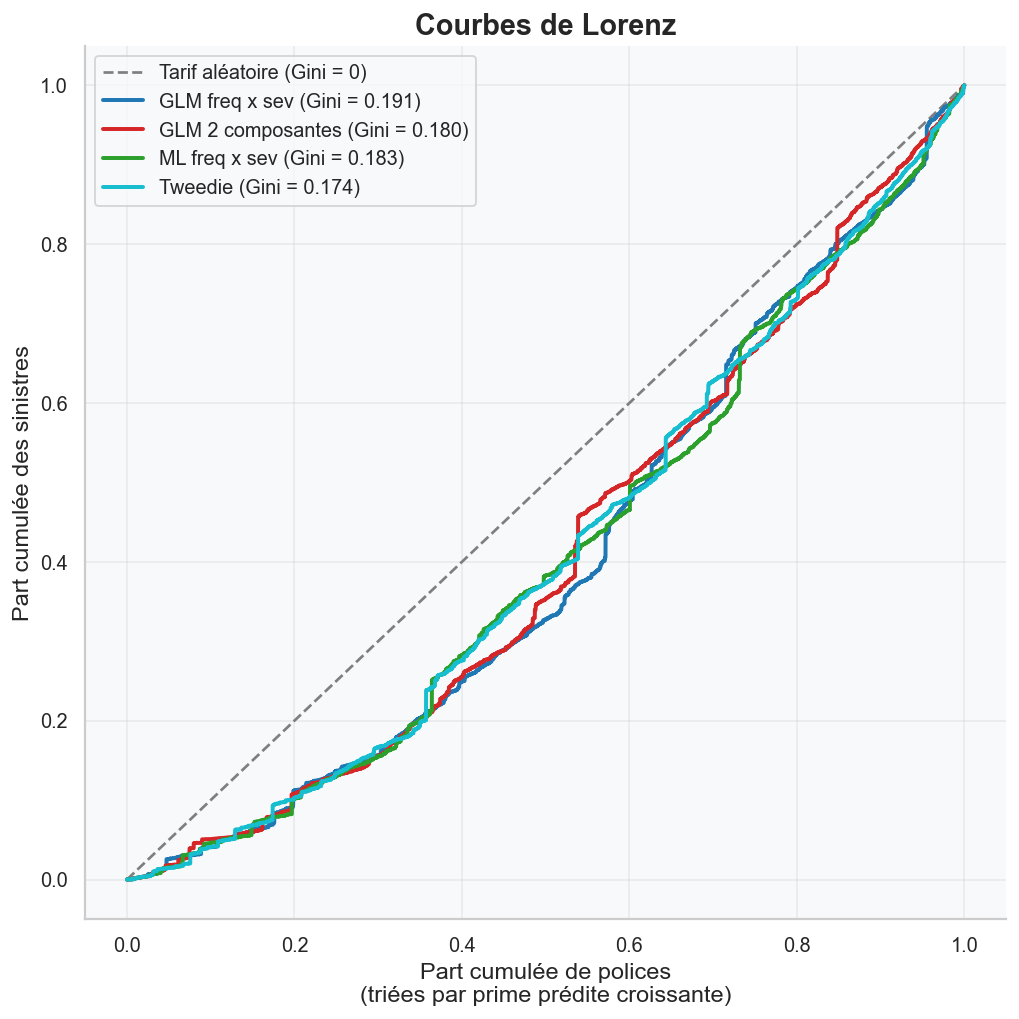

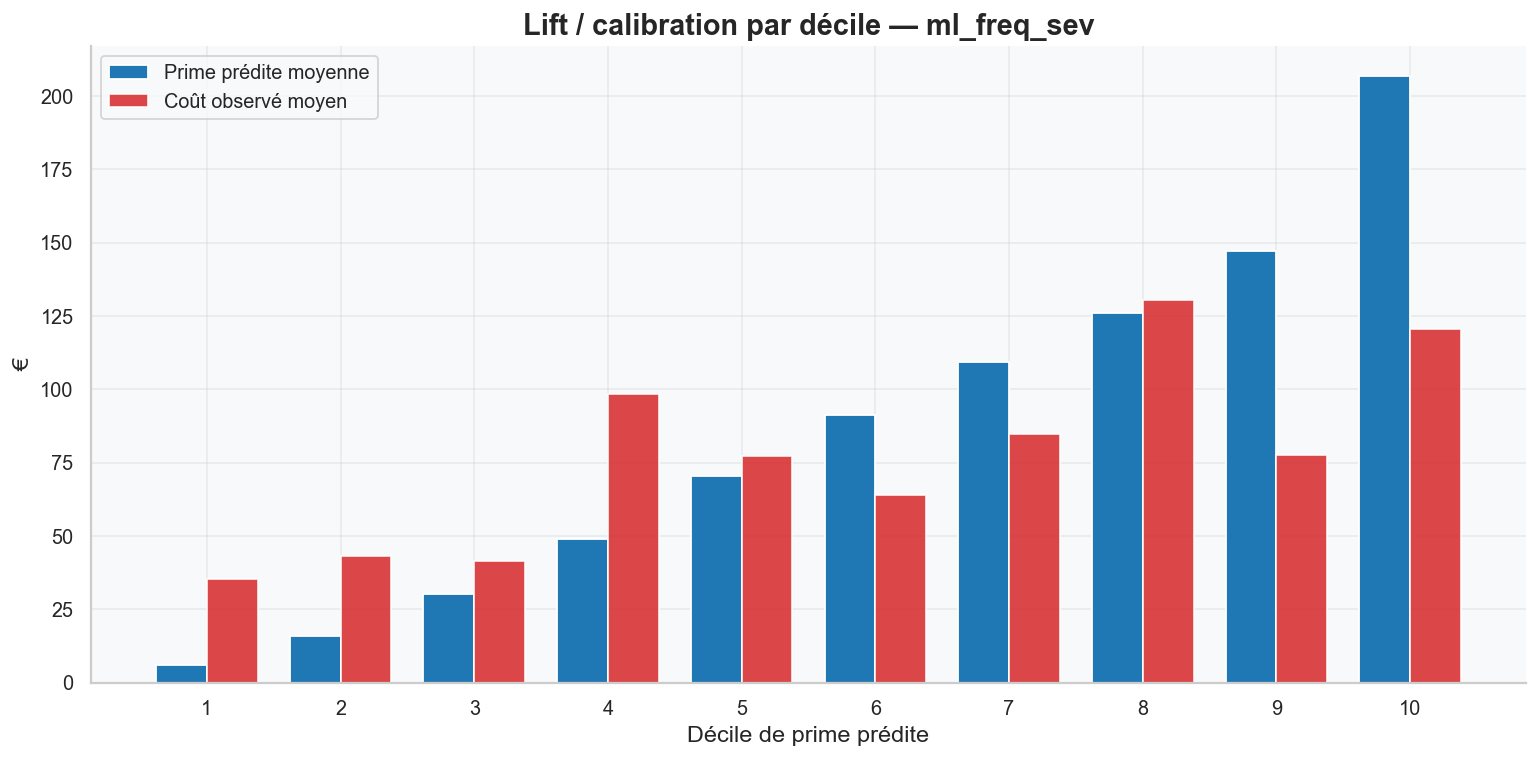

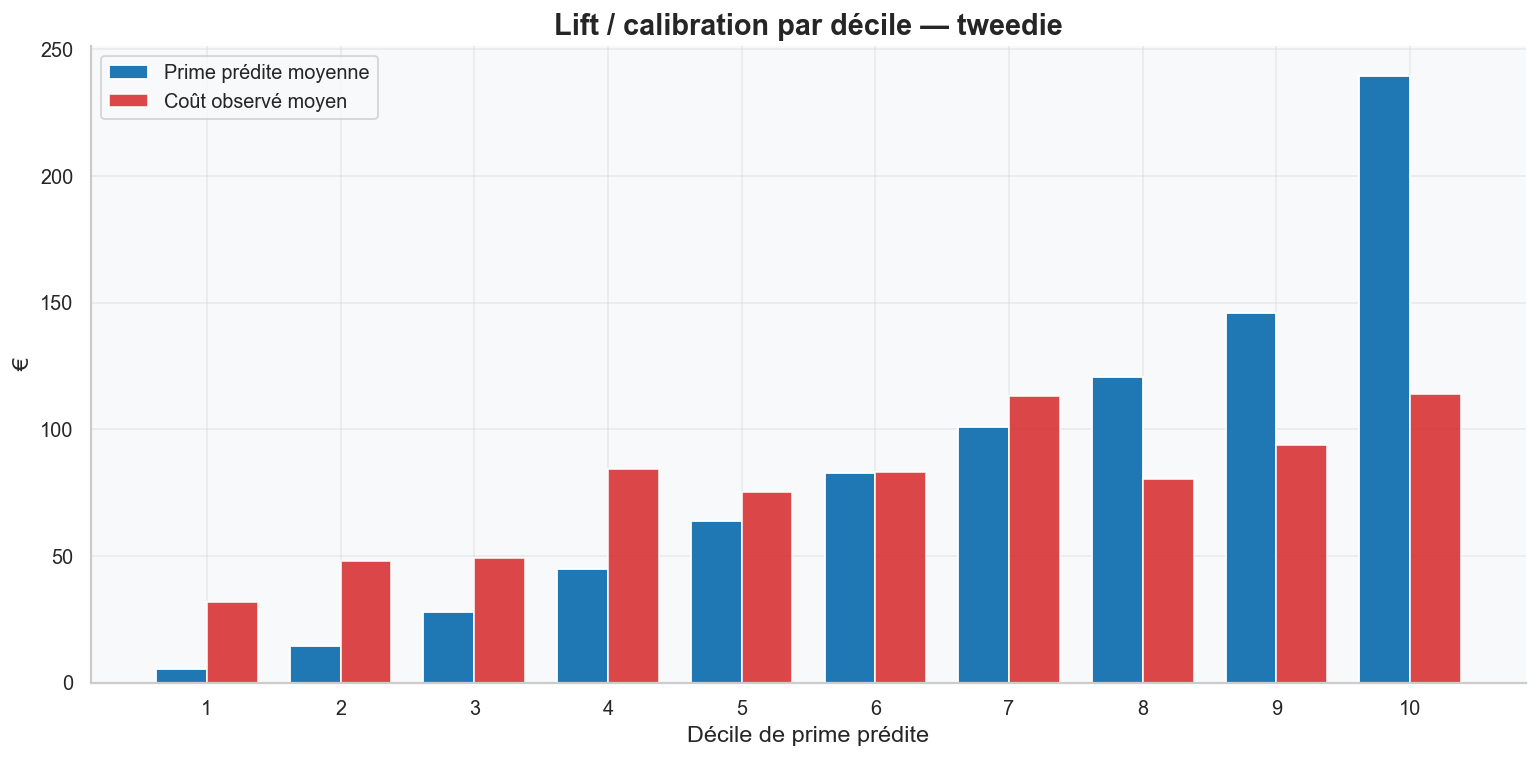

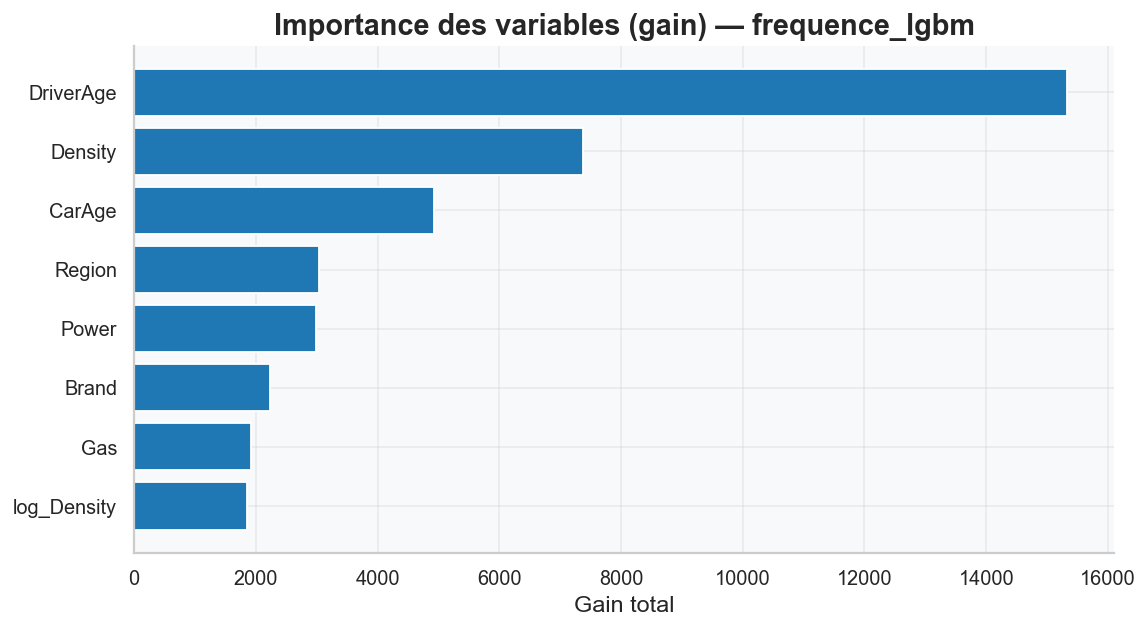

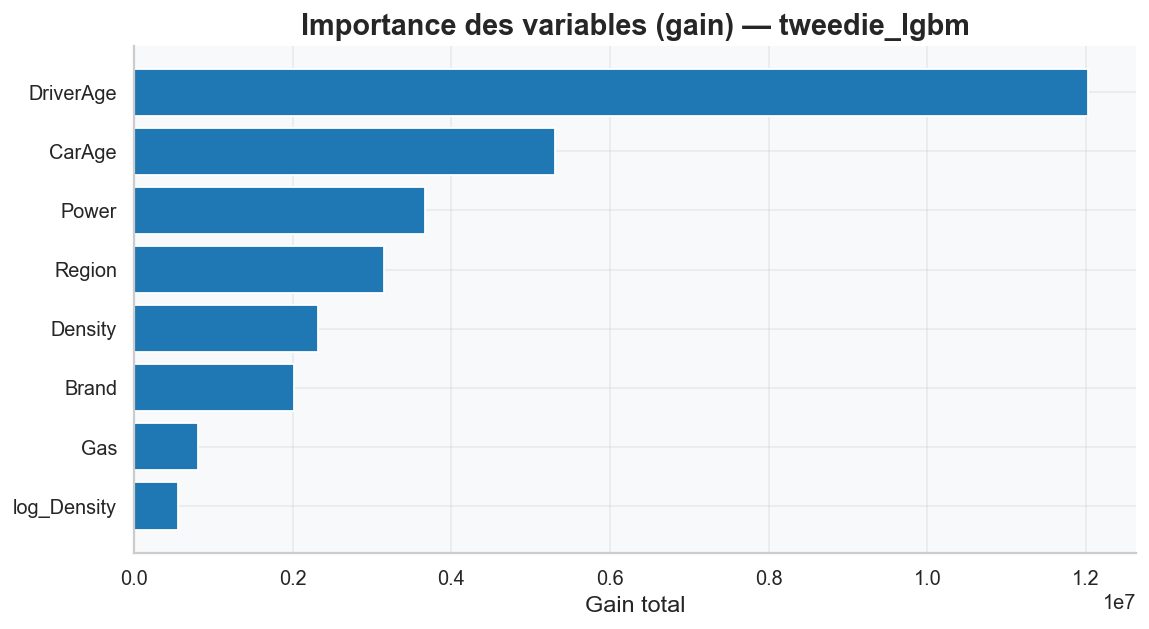

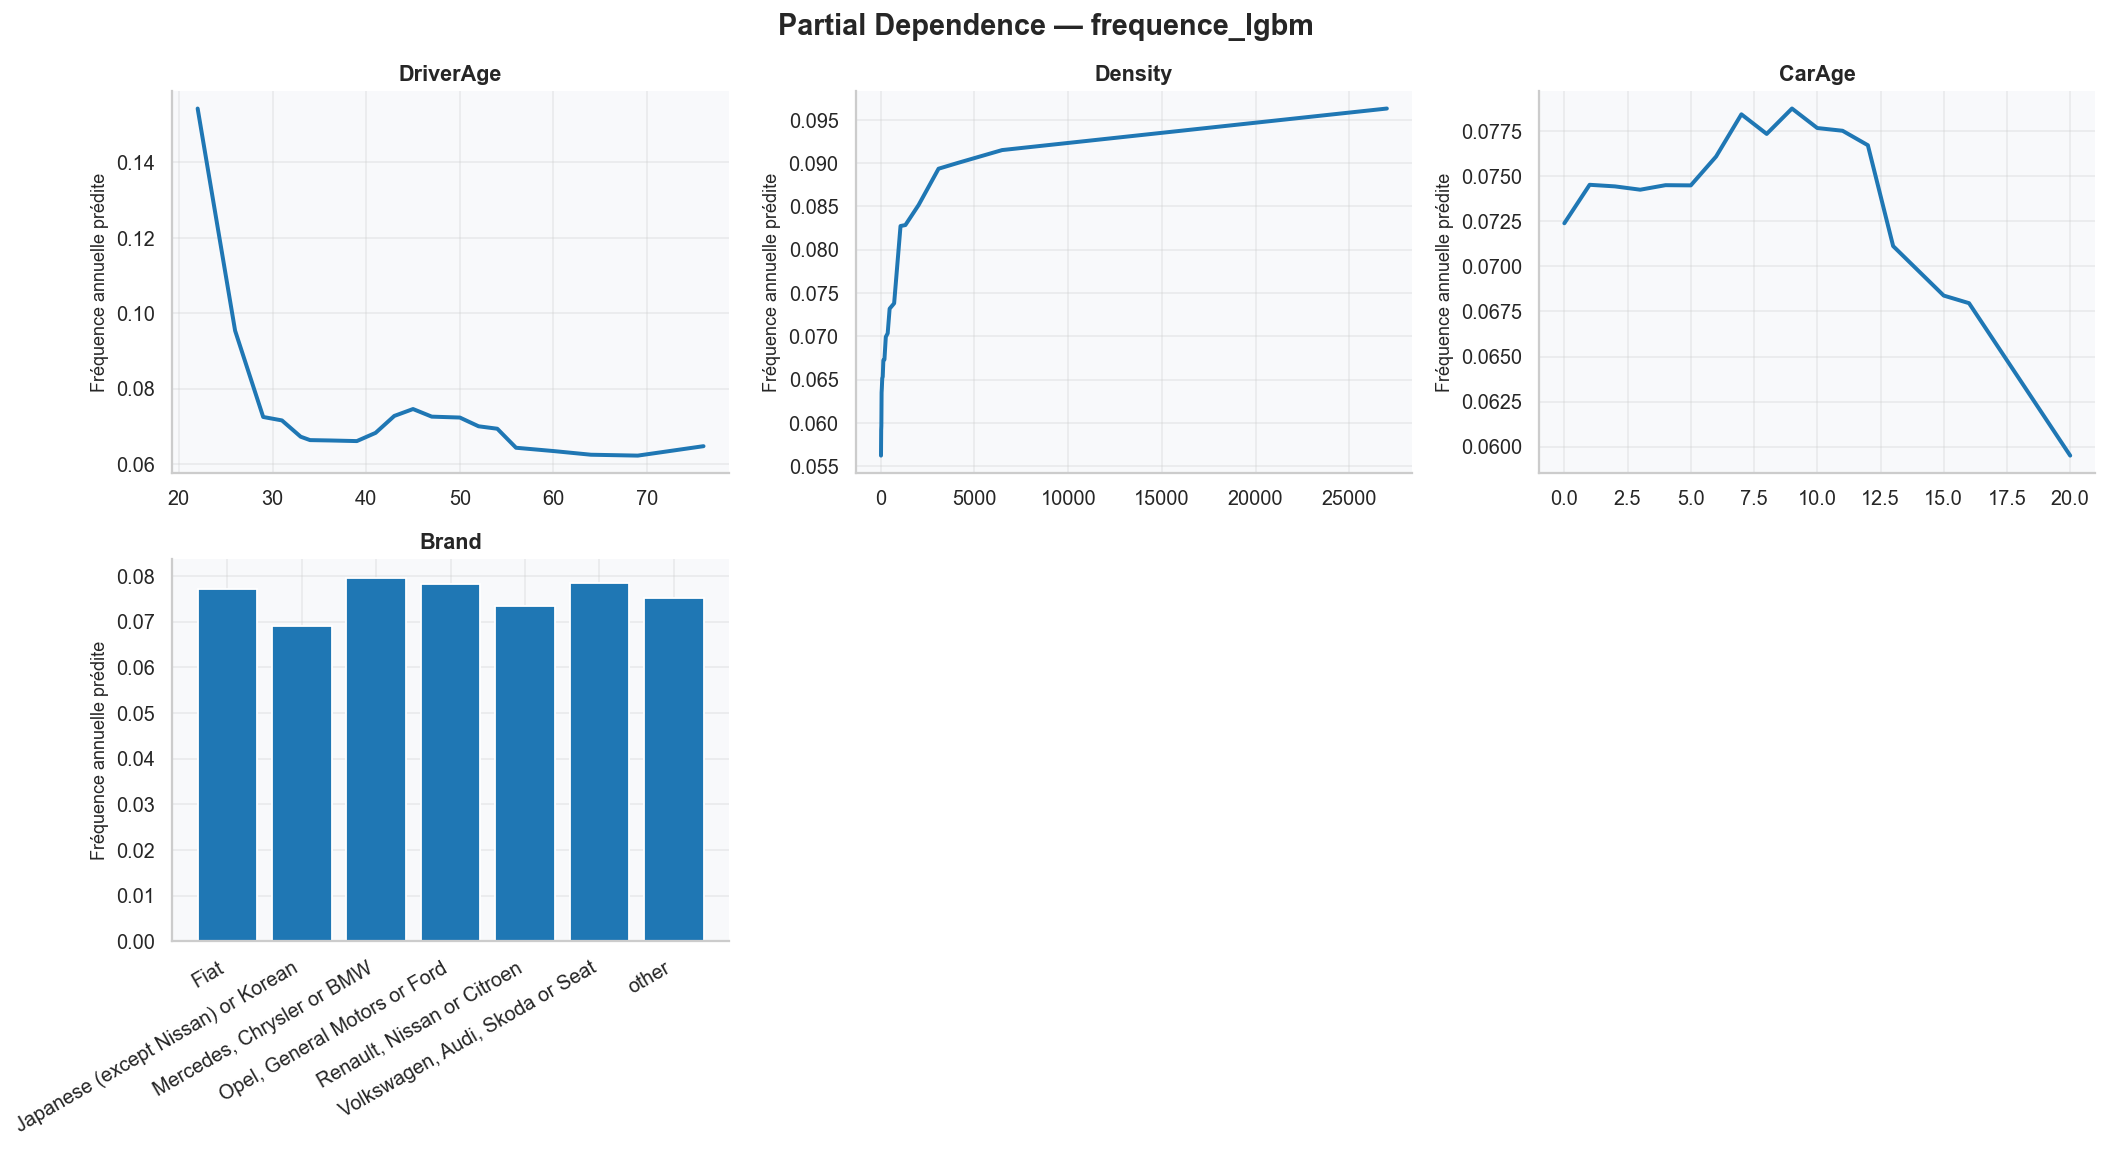

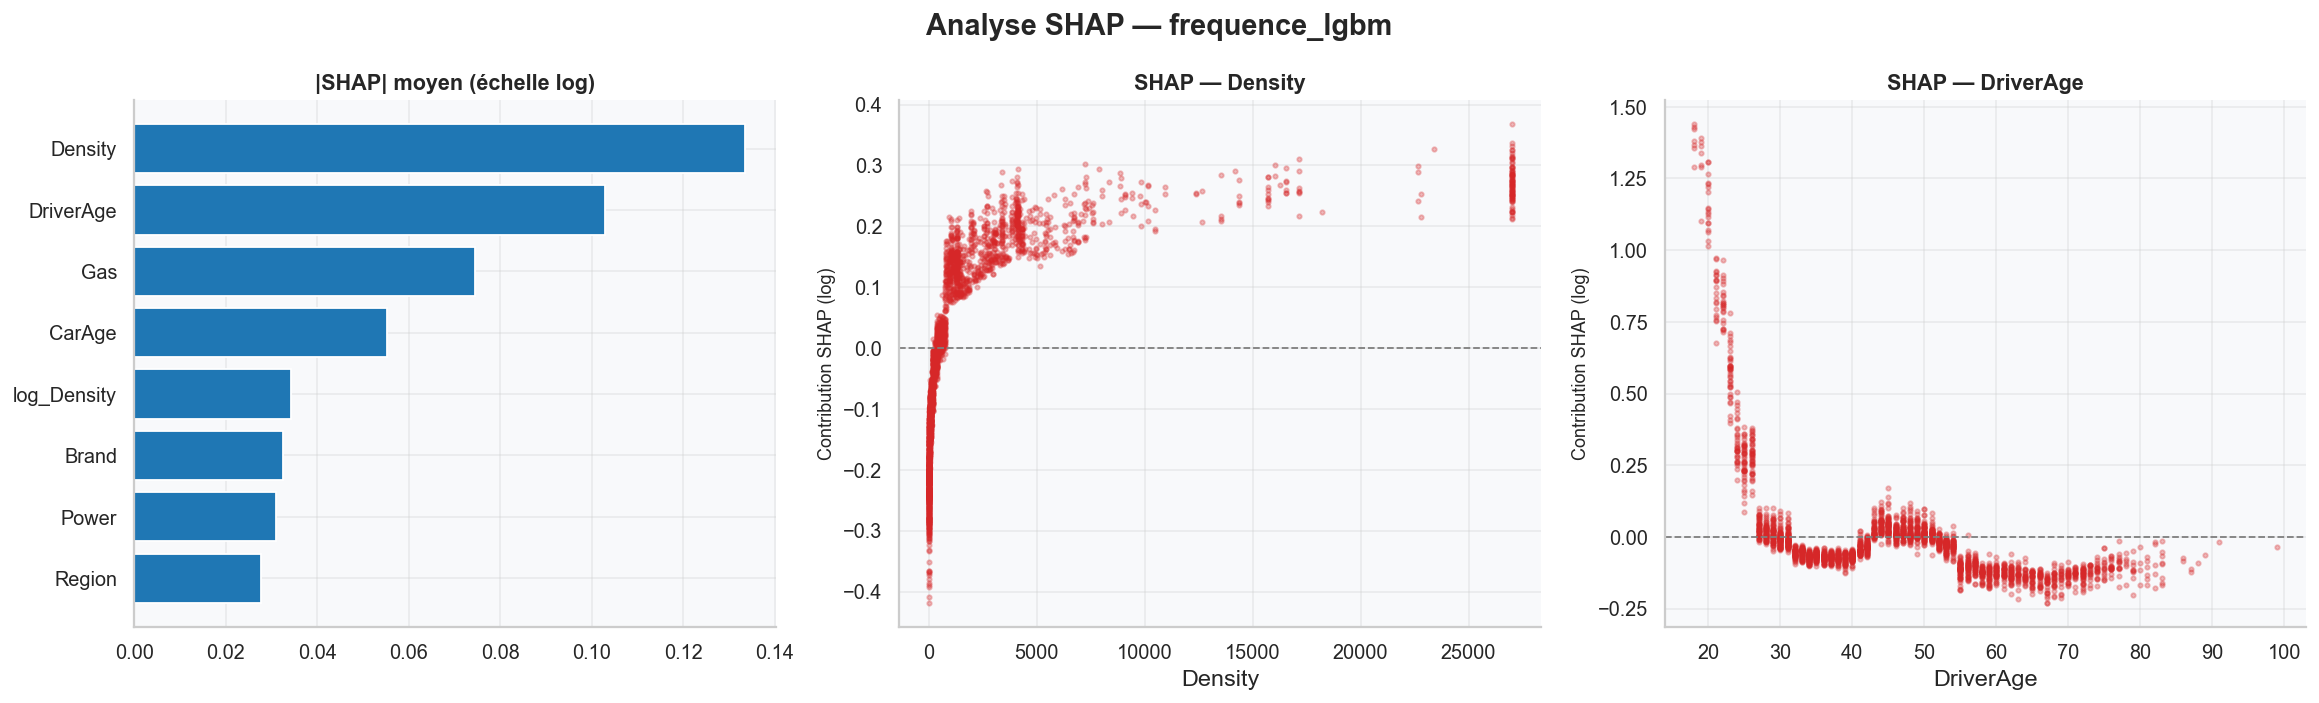

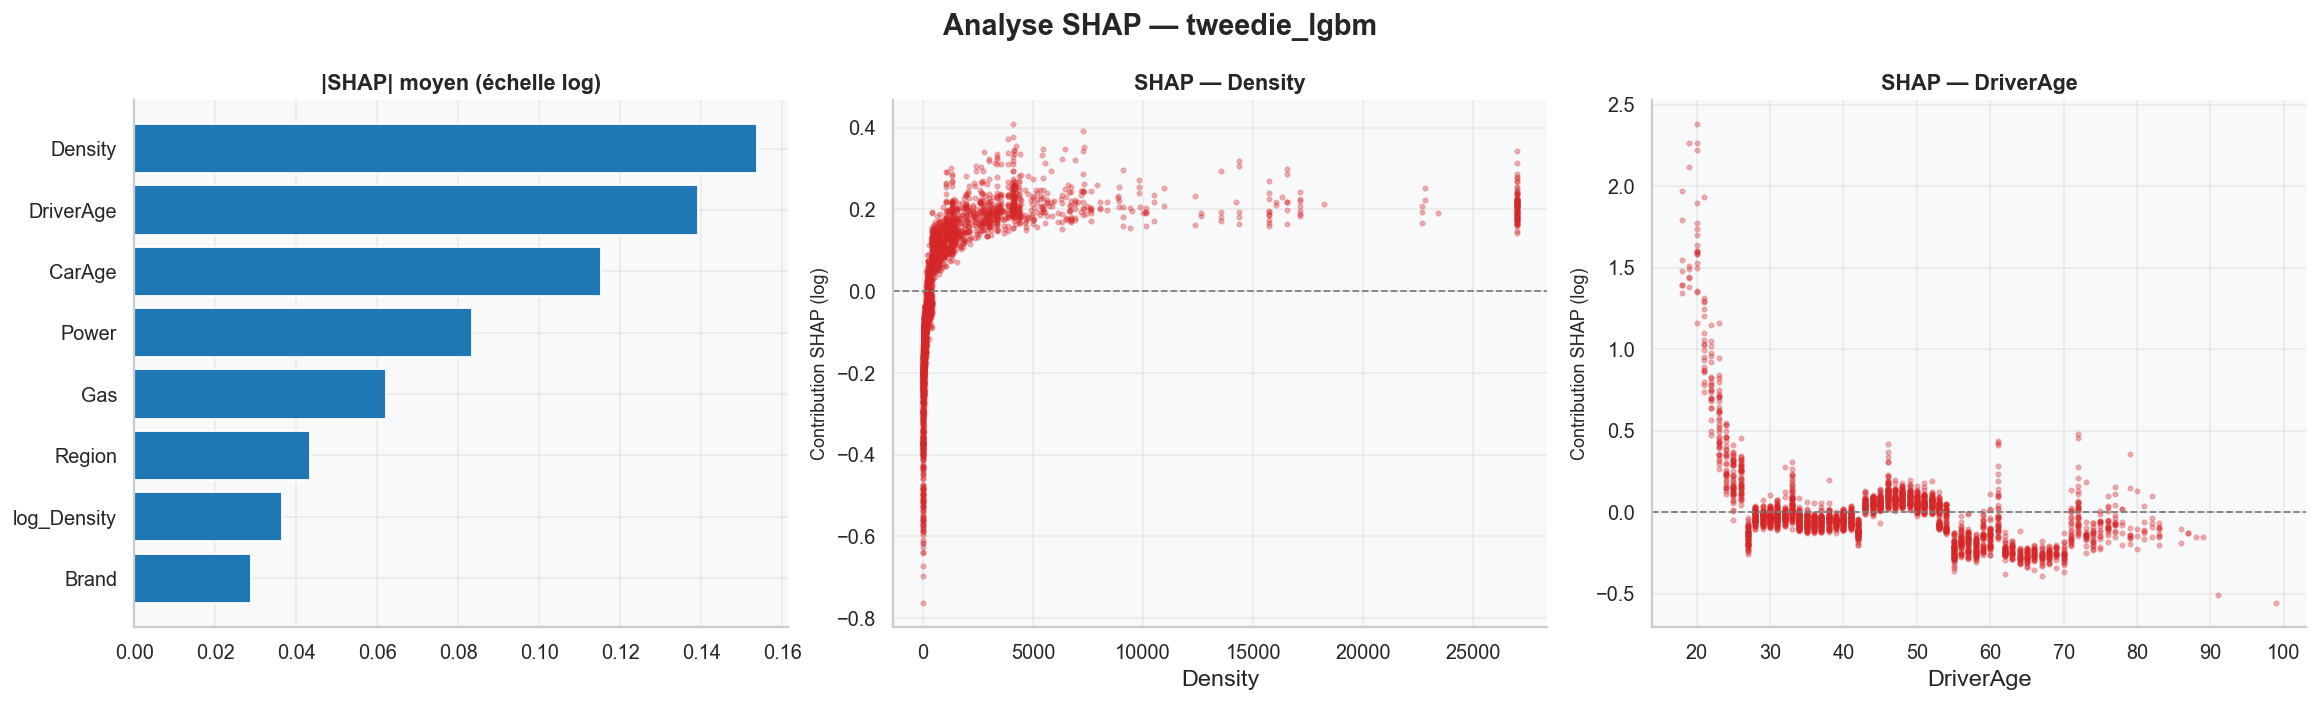

In [28]:
from models.ml_evaluate import lorenz_curve, gini
from visualization.ml_plots import (
    plot_lift,
    plot_lorenz_curves,
    plot_feature_importance,
    plot_pdp,
    plot_shap_summary,
)

# Lorenz : pouvoir de segmentation des quatre tarifs
curves = {}
for name, col in [
    ("GLM freq x sev", "pure_premium"),
    ("GLM 2 composantes", "pure_premium_2comp"),
    ("ML freq x sev", "pure_premium_ml"),
    ("Tweedie", "pure_premium_tweedie"),
]:
    x, y = lorenz_curve(eval_df["ClaimAmount_total"], eval_df[col])
    g = gini(eval_df["ClaimAmount_total"], eval_df[col])
    curves[name] = (x, y, g)

plot_lorenz_curves(curves)

# Lift / calibration par décile
plot_lift(
    lift_table(
        eval_df["ClaimAmount_total"], eval_df["pure_premium_ml"]
    ),
    "ml_freq_sev"
)
plot_lift(
    lift_table(
        eval_df["ClaimAmount_total"], eval_df["pure_premium_tweedie"]
    ),
    "tweedie"
)

# Importance des variables (gain)
plot_feature_importance(ml_freq_model.model, "frequence_lgbm")
plot_feature_importance(tweedie_model.model, "tweedie_lgbm")

# Partial Dependence : effets marginaux moyens,
# à confronter aux relativités du GLM
plot_pdp(
    ml_freq_model.predict,
    ml_test_freq[FEATURES],
    ["DriverAge", "Density", "CarAge", "Brand"],
    "frequence_lgbm",
    ylabel="Fréquence annuelle prédite"
)

# SHAP (TreeSHAP natif LightGBM, échelle log)
plot_shap_summary(
    ml_freq_model.model, ml_test_freq[FEATURES], "frequence_lgbm"
)
plot_shap_summary(
    tweedie_model.model, ml_test_freq[FEATURES], "tweedie_lgbm"
)